# 1. Setup

In [ ]:
# Σύνδεση Google Drive και εκκίνηση Spark session

from google.colab import drive
drive.mount('/content/drive')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd

spark = (
    SparkSession.builder
    .appName("GDELT_Clean")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)

print("Spark session ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Spark session ready.


# 2. Frontex Data

In [ ]:
# Φόρτωση αρχείου Frontex με γραμμή επικεφαλίδων
path = "/content/drive/MyDrive/Monthly_detections_of_IBC_13_20260203.xlsx"
df_frontex = pd.read_excel(path, header=1)

# Υπολογισμός συνολικών καταγραφών ανά γραμμή ως άθροισμα όλων των
# αριθμητικών μηνιαίων στηλών
numeric_cols = df_frontex.select_dtypes(include="number").columns
df_frontex["total_detections_row"] = df_frontex[numeric_cols].sum(axis=1)

# Συγκεντρωτικός πίνακας συνολικών καταγραφών ανά εθνικότητα
agg = (
    df_frontex
    .groupby("Nationality", as_index=False)["total_detections_row"]
    .sum()
    .rename(columns={"total_detections_row": "total_detections"})
)

# Πρώτο φίλτρο: κρατούνται μόνο εθνικότητες με ουσιαστικό συνολικό
# όγκο καταγραφών
MIN_TOTAL = 300
core = agg[agg["total_detections"] >= MIN_TOTAL].copy()

# Εξαίρεση "Ukraine" (κυρίως ενδοευρωπαϊκές προσφυγικές ροές)
core = core[~core["Nationality"].str.contains("Ukraine", case=False, na=False)]

# Ταξινόμηση κατά φθίνουσα σειρά
core_sorted = (
    core
    .sort_values("total_detections", ascending=False)
    .reset_index(drop=True)
)

# Υπολογισμός μεριδίου και αθροιστικού μεριδίου
total_all = core_sorted["total_detections"].sum()
core_sorted["share"] = core_sorted["total_detections"] / total_all
core_sorted["cum_share"] = core_sorted["share"].cumsum()

# Δεύτερο φίλτρο: εθνικότητες έως ~95% του συνολικού όγκου
CUTOFF = 0.95
core_top = core_sorted[core_sorted["cum_share"] <= CUTOFF].copy()

# Τελική λίστα εθνικοτήτων για χρήση στο Spark
core_nationalities = core_top["Nationality"].tolist()

print("Χώρες που περνούν το όριο και καλύπτουν ~95% των detections:")
print(core_top[["Nationality", "total_detections", "share", "cum_share"]])

print(f"\nΣύνολο χωρών μετά το 2ο φίλτρο: {len(core_top)}")
print("\nΛίστα για χρήση στο Spark:")
print(core_nationalities)

Χώρες που περνούν το όριο και καλύπτουν ~95% των detections:
                          Nationality  total_detections     share  cum_share
0                               Syria           1181897  0.233676   0.233676
1                             Unknown            683988  0.135233   0.368909
2                         Afghanistan            602320  0.119086   0.487995
3                                Iraq            200907  0.039722   0.527717
4                            Pakistan            155412  0.030727   0.558443
5                             Eritrea            153632  0.030375   0.588818
6                             Morocco            148401  0.029341   0.618159
7                          Bangladesh            140674  0.027813   0.645972
8                             Tunisia            137321  0.027150   0.673122
9                             Albania            135335  0.026757   0.699880
10                            Algeria            123729  0.024463   0.724342
11             

In [ ]:
# Αφαίρεση μη αξιοποιήσιμων κατηγοριών από την core λίστα
remove_items = [
    "Unknown",
    "Unspecified sub-Saharan nationals"
]

filtered_core = [c for c in core_nationalities if c not in remove_items]

# Έλεγχος τελικού αποτελέσματος
print("Τελική καθαρή λίστα χωρών προέλευσης:")
for c in filtered_core:
    print("-", c)

print("\nΣύνολο χωρών:", len(filtered_core))

Τελική καθαρή λίστα χωρών προέλευσης:
- Syria
- Afghanistan
- Iraq
- Pakistan
- Eritrea
- Morocco
- Bangladesh
- Tunisia
- Albania
- Algeria
- Nigeria
- Egypt
- Guinea
- Mali
- Somalia
- Côte d'Ivoire
- Senegal
- Türkiye
- Sudan
- Gambia
- Palestine^
- Iran
- Kosovo*

Σύνολο χωρών: 23


In [ ]:
# Υπολογισμός συνολικών detections ανά Route
numeric_cols_all = df_frontex.select_dtypes(include="number").columns.tolist()
numeric_cols_all = [c for c in numeric_cols_all if c != "total_detections_row"]

df_route_totals = (
    df_frontex
    .groupby("Route")[numeric_cols_all]
    .sum()
)

# Προσθήκη συνολικού αθροίσματος ανά Route
df_route_totals["total_detections"] = df_route_totals.sum(axis=1)

# Ταξινόμηση Routes με βάση τον συνολικό όγκο detections
df_route_totals = df_route_totals[["total_detections"]].sort_values(
    "total_detections", ascending=False
)

print("Συνολικά detections ανά Route (ταξινομημένα):")
print(df_route_totals)

Συνολικά detections ανά Route (ταξινομημένα):
                                       total_detections
Route                                                  
Eastern Mediterranean Route                     1780864
Western Balkan Route                            1372661
Central Mediterranean Route                     1303029
Western Mediterranean Route                      264881
Western African Route                            175776
Circular Route from Albania to Greece            135637
Eastern Borders Route                             62414
Black Sea Route                                    1379
Other                                                73


In [ ]:
# Επιλογή των τεσσάρων κυρίαρχων SMR routes (όπως προέκυψαν από την ταξινόμηση)
routes_keep = [
    "Eastern Mediterranean Route",
    "Central Mediterranean Route",
    "Western Balkan Route",
    "Western African Route"
]

df_routes = df_frontex[df_frontex["Route"].isin(routes_keep)].copy()

print("Επιλεγμένες SMR routes για πρόβλεψη:")
print(df_routes["Route"].unique())

Επιλεγμένες SMR routes για πρόβλεψη:
['Eastern Mediterranean Route' 'Central Mediterranean Route'
 'Western African Route' 'Western Balkan Route']


In [ ]:
# Επιλογή όλων των αριθμητικών στηλών (μηνιαίες καταγραφές)
numeric_cols = df_routes.select_dtypes(include="number").columns.tolist()

# Μετατροπή από wide σε long μορφή (Route – Nationality – Month)
df_long = df_routes.melt(
    id_vars=["Route", "Nationality"],
    value_vars=numeric_cols,
    var_name="year_month",
    value_name="detections"
)

# Αφαίρεση κενών και μηδενικών τιμών
df_long = df_long.dropna(subset=["detections"])
df_long = df_long[df_long["detections"] > 0]

# Συγκεντρωτικός πίνακας: σύνολο μηνιαίων detections ανά Route
df_route_month = (
    df_long
    .groupby(["Route", "year_month"], as_index=False)["detections"]
    .sum()
    .rename(columns={"detections": "total_detections"})
)

# Μετατροπή year_month από μορφή APR2024 σε δύο στήλες: label και κλειδί YYYYMM
month_map = {
    "JAN": "01", "FEB": "02", "MAR": "03", "APR": "04",
    "MAY": "05", "JUN": "06", "JUL": "07", "AUG": "08",
    "SEP": "09", "OCT": "10", "NOV": "11", "DEC": "12"
}

# Κρατά την αρχική μορφή σαν label
df_route_month["year_month_label"] = df_route_month["year_month"]

# Φτιάχνεται μορφή YYYYMM για join με GDELT
df_route_month["year"] = df_route_month["year_month"].str[-4:]
df_route_month["month"] = df_route_month["year_month"].str[:3].map(month_map)
df_route_month["year_month"] = df_route_month["year"] + df_route_month["month"]

df_route_month = df_route_month.drop(columns=["year", "month"])

# Αποθήκευση route-level target dataset
route_target_path = "/content/drive/MyDrive/route_month_target.parquet"
df_route_month.to_parquet(route_target_path, index=False)

print("Saved route-level target table at:", route_target_path)

Saved route-level target table at: /content/drive/MyDrive/route_month_target.parquet


# 3. GDELT DATA

In [ ]:
import os
import requests

# Φάκελος αποθήκευσης για το 2023
save_dir = "/content/drive/MyDrive/gdelt_events_2023_2024_2025"
os.makedirs(save_dir, exist_ok=True)

# Βασικό URL GDELT
base = "http://data.gdeltproject.org/events/"
year = "2023"

# Loop σε όλους τους πιθανούς μήνες και ημέρες
for m in range(1, 13):
    for d in range(1, 32):

        # Όνομα αρχείου μορφής YYYYMMDD.export.CSV.zip
        fname = f"{year}{m:02d}{d:02d}.export.CSV.zip"
        url = base + fname
        out = os.path.join(save_dir, fname)

        # Έλεγχος αν υπάρχει το αρχείο στον server
        r = requests.head(url)

        # Αν υπάρχει (status 200), το κατεβάζει
        if r.status_code == 200:
            print("OK  ", fname)
            os.system(f'wget -q "{url}" -O "{out}"')
        else:
            # Αν δεν υπάρχει το προσπερνάει
            print("MISS", fname)

OK   20230101.export.CSV.zip
OK   20230102.export.CSV.zip
OK   20230103.export.CSV.zip
OK   20230104.export.CSV.zip
OK   20230105.export.CSV.zip
OK   20230106.export.CSV.zip
OK   20230107.export.CSV.zip
OK   20230108.export.CSV.zip
OK   20230109.export.CSV.zip
OK   20230110.export.CSV.zip
OK   20230111.export.CSV.zip
OK   20230112.export.CSV.zip
OK   20230113.export.CSV.zip
OK   20230114.export.CSV.zip
OK   20230115.export.CSV.zip
OK   20230116.export.CSV.zip
OK   20230117.export.CSV.zip
OK   20230118.export.CSV.zip
OK   20230119.export.CSV.zip
OK   20230120.export.CSV.zip
OK   20230121.export.CSV.zip
OK   20230122.export.CSV.zip
OK   20230123.export.CSV.zip
OK   20230124.export.CSV.zip
OK   20230125.export.CSV.zip
OK   20230126.export.CSV.zip
OK   20230127.export.CSV.zip
OK   20230128.export.CSV.zip
OK   20230129.export.CSV.zip
OK   20230130.export.CSV.zip
OK   20230131.export.CSV.zip
OK   20230201.export.CSV.zip
OK   20230202.export.CSV.zip
OK   20230203.export.CSV.zip
OK   20230204.

In [ ]:
import os
import requests

# Φάκελος αποθήκευσης για το 2024
save_dir = "/content/drive/MyDrive/gdelt_events_2023_2024_2025"
os.makedirs(save_dir, exist_ok=True)

# Βασικό URL GDELT
base = "http://data.gdeltproject.org/events/"
year = "2024"

# Loop σε όλους τους πιθανούς μήνες και ημέρες
for m in range(1, 13):
    for d in range(1, 32):

        # Όνομα αρχείου μορφής YYYYMMDD.export.CSV.zip
        fname = f"{year}{m:02d}{d:02d}.export.CSV.zip"
        url = base + fname
        out = os.path.join(save_dir, fname)

        # Έλεγχος αν υπάρχει το αρχείο στον server
        r = requests.head(url)

        # Αν υπάρχει (status 200), το κατεβάζει
        if r.status_code == 200:
            print("OK  ", fname)
            os.system(f'wget -q "{url}" -O "{out}"')
        else:
            # Αν δεν υπάρχει το προσπερνάει
            print("MISS", fname)

OK   20240101.export.CSV.zip
OK   20240102.export.CSV.zip
OK   20240103.export.CSV.zip
OK   20240104.export.CSV.zip
OK   20240105.export.CSV.zip
OK   20240106.export.CSV.zip
OK   20240107.export.CSV.zip
OK   20240108.export.CSV.zip
OK   20240109.export.CSV.zip
OK   20240110.export.CSV.zip
OK   20240111.export.CSV.zip
OK   20240112.export.CSV.zip
OK   20240113.export.CSV.zip
OK   20240114.export.CSV.zip
OK   20240115.export.CSV.zip
OK   20240116.export.CSV.zip
OK   20240117.export.CSV.zip
OK   20240118.export.CSV.zip
OK   20240119.export.CSV.zip
OK   20240120.export.CSV.zip
OK   20240121.export.CSV.zip
OK   20240122.export.CSV.zip
OK   20240123.export.CSV.zip
OK   20240124.export.CSV.zip
OK   20240125.export.CSV.zip
OK   20240126.export.CSV.zip
OK   20240127.export.CSV.zip
OK   20240128.export.CSV.zip
OK   20240129.export.CSV.zip
OK   20240130.export.CSV.zip
OK   20240131.export.CSV.zip
OK   20240201.export.CSV.zip
OK   20240202.export.CSV.zip
OK   20240203.export.CSV.zip
OK   20240204.

In [ ]:
import os
import requests

# Φάκελος αποθήκευσης για το 2025
save_dir = "/content/drive/MyDrive/gdelt_events_2023_2024_2025"
os.makedirs(save_dir, exist_ok=True)

# Βασικό URL GDELT
base = "http://data.gdeltproject.org/events/"
year = "2025"

# Loop σε όλους τους πιθανούς μήνες και ημέρες
for m in range(1, 13):
    for d in range(1, 32):

        # Όνομα αρχείου μορφής YYYYMMDD.export.CSV.zip
        fname = f"{year}{m:02d}{d:02d}.export.CSV.zip"
        url = base + fname
        out = os.path.join(save_dir, fname)

        # Έλεγχος αν υπάρχει το αρχείο στον server
        r = requests.head(url)

        # Αν υπάρχει (status 200), το κατεβάζει
        if r.status_code == 200:
            print("OK  ", fname)
            os.system(f'wget -q "{url}" -O "{out}"')
        else:
            # Αν δεν υπάρχει το προσπερνάει
            print("MISS", fname)

OK   20250101.export.CSV.zip
OK   20250102.export.CSV.zip
OK   20250103.export.CSV.zip
OK   20250104.export.CSV.zip
OK   20250105.export.CSV.zip
OK   20250106.export.CSV.zip
OK   20250107.export.CSV.zip
OK   20250108.export.CSV.zip
OK   20250109.export.CSV.zip
OK   20250110.export.CSV.zip
OK   20250111.export.CSV.zip
OK   20250112.export.CSV.zip
OK   20250113.export.CSV.zip
OK   20250114.export.CSV.zip
OK   20250115.export.CSV.zip
OK   20250116.export.CSV.zip
OK   20250117.export.CSV.zip
OK   20250118.export.CSV.zip
OK   20250119.export.CSV.zip
OK   20250120.export.CSV.zip
OK   20250121.export.CSV.zip
OK   20250122.export.CSV.zip
OK   20250123.export.CSV.zip
OK   20250124.export.CSV.zip
OK   20250125.export.CSV.zip
OK   20250126.export.CSV.zip
OK   20250127.export.CSV.zip
OK   20250128.export.CSV.zip
OK   20250129.export.CSV.zip
OK   20250130.export.CSV.zip
OK   20250131.export.CSV.zip
OK   20250201.export.CSV.zip
OK   20250202.export.CSV.zip
OK   20250203.export.CSV.zip
OK   20250204.

In [ ]:
# Έλεγχος συνολικού μεγέθους των αρχείων που κατέβηκαν
!du -sh "/content/drive/MyDrive/gdelt_events_2023_2024_2025"

8.0G	/content/drive/MyDrive/gdelt_events_2023_2024_2025


In [ ]:
# Δημιουργία φακέλου εξαγωγής μέσα στο Google Drive
!mkdir -p "/content/drive/MyDrive/gdelt_events_unzipped_2023_2024_2025"

# Unzip ΜΟΝΟ όσα δεν υπάρχουν ήδη (no overwrite)
!unzip -nq "/content/drive/MyDrive/gdelt_events_2023_2024_2025/*.zip" \
       -d "/content/drive/MyDrive/gdelt_events_unzipped_2023_2024_2025"


1077 archives were successfully processed.


In [ ]:
# Έλεγχος συνολικού μεγέθους των αποσυμπιεσμένων CSV στο Drive
!du -sh "/content/drive/MyDrive/gdelt_events_unzipped_2023_2024_2025"

49G	/content/drive/MyDrive/gdelt_events_unzipped_2023_2024_2025


In [ ]:
# Φόρτωση όλων των CSV από τον φάκελο με τα αποσυμπιεσμένα αρχεία
# GDELT 2023-2024–2025

df_gdelt = spark.read.csv(
    "/content/drive/MyDrive/gdelt_events_unzipped_2023_2024_2025/*.CSV",
    sep="\t",          # GDELT = tab-separated
    header=False,
    inferSchema=False
)

# Έλεγχος 5 πρώτων γραμμών
df_gdelt.show(5, truncate=False)

+----------+--------+------+----+---------+----+--------+----+----+----+----+----+----+----+----+------+---------------+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+------------------+----+-----------------------+----+----+-------+--------+--------+----+------------------------------------------------+----+----+-------+--------+------+----+------------------------------------------------+----+----+-------+--------+--------+--------+-----------------------------------------------------------------------------------------------------------------------------+
|_c0       |_c1     |_c2   |_c3 |_c4      |_c5 |_c6     |_c7 |_c8 |_c9 |_c10|_c11|_c12|_c13|_c14|_c15  |_c16           |_c17|_c18|_c19|_c20|_c21|_c22|_c23|_c24|_c25|_c26|_c27|_c28|_c29|_c30|_c31|_c32|_c33|_c34              |_c35|_c36                   |_c37|_c38|_c39   |_c40    |_c41    |_c42|_c43                                            |_c44|_c45|_c46   |_c47    |_c48  |_c49|_c50           

In [ ]:
# Αντιστοίχιση ονομάτων στηλών (schema GDELT v2 events)
cols = [
    "event_id","event_date","event_month_year","event_year","event_fraction_date",
    "entity1_code","entity1_name","entity1_country","entity1_group",
    "entity1_ethnicity","entity1_religion1","entity1_religion2",
    "entity1_type1","entity1_type2","entity1_type3",
    "entity2_code","entity2_name","entity2_country","entity2_group",
    "entity2_ethnicity","entity2_religion1","entity2_religion2",
    "entity2_type1","entity2_type2","entity2_type3",
    "is_root_event","event_code","event_code_base","event_category",
    "event_class","event_impact","mention_count","source_count","article_count",
    "sentiment_score",
    "entity1_loc_type","entity1_loc_name","entity1_loc_country",
    "entity1_loc_admin1","entity1_lat","entity1_long","entity1_feature_id",
    "entity2_loc_type","entity2_loc_name","entity2_loc_country",
    "entity2_loc_admin1","entity2_lat","entity2_long","entity2_feature_id",
    "event_loc_type","event_loc_name","event_loc_country",
    "event_loc_admin1","event_lat","event_long","event_feature_id",
    "date_added","source_url"
]

df_gdelt = df_gdelt.toDF(*cols)

# Γρήγορος έλεγχος schema + δείγμα γραμμών
df_gdelt.printSchema()
df_gdelt.show(20, truncate=False)

root
 |-- event_id: string (nullable = true)
 |-- event_date: string (nullable = true)
 |-- event_month_year: string (nullable = true)
 |-- event_year: string (nullable = true)
 |-- event_fraction_date: string (nullable = true)
 |-- entity1_code: string (nullable = true)
 |-- entity1_name: string (nullable = true)
 |-- entity1_country: string (nullable = true)
 |-- entity1_group: string (nullable = true)
 |-- entity1_ethnicity: string (nullable = true)
 |-- entity1_religion1: string (nullable = true)
 |-- entity1_religion2: string (nullable = true)
 |-- entity1_type1: string (nullable = true)
 |-- entity1_type2: string (nullable = true)
 |-- entity1_type3: string (nullable = true)
 |-- entity2_code: string (nullable = true)
 |-- entity2_name: string (nullable = true)
 |-- entity2_country: string (nullable = true)
 |-- entity2_group: string (nullable = true)
 |-- entity2_ethnicity: string (nullable = true)
 |-- entity2_religion1: string (nullable = true)
 |-- entity2_religion2: string (

In [ ]:
# Φιλτράρισμα των απαραίτητων στηλών

cols_keep = [
    "event_id",
    "event_date", "event_month_year", "event_year",

    "event_code", "event_category", "event_class",
    "is_root_event", "mention_count",
    "sentiment_score",

    "entity1_country", "entity2_country",
    "entity1_group", "entity2_group",
    "entity1_type1", "entity2_type1",

    "event_loc_admin1",
    "event_lat", "event_long", "event_loc_name"
]

# Φιλτράρισμα βάσει έτους
df_selected = (
    df_gdelt
    .filter(F.col("event_year").isin(["2023","2024", "2025"]))
    .select(cols_keep)
)


# ---> Έλεγχος 5 πρώτων γραμμών
df_selected.show(5, truncate=False)

+----------+----------+----------------+----------+----------+--------------+-----------+-------------+-------------+------------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+------------------------------------------------+
|event_id  |event_date|event_month_year|event_year|event_code|event_category|event_class|is_root_event|mention_count|sentiment_score   |entity1_country|entity2_country|entity1_group|entity2_group|entity1_type1|entity2_type1|event_loc_admin1|event_lat|event_long|event_loc_name                                  |
+----------+----------+----------------+----------+----------+--------------+-----------+-------------+-------------+------------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+------------------------------------------------+
|1090666046|20230222  |202302          |2023      |043       |04

In [ ]:
# Φίλτρο push factors: κρατάει μόνο γεγονότα που συνέβησαν σε χώρες προέλευσης

df_filtered = df_selected.filter(
    F.col("event_loc_name").isin(filtered_core)
)

df_filtered.show(20, truncate=False)

+----------+----------+----------------+----------+----------+--------------+-----------+-------------+-------------+------------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+--------------+
|event_id  |event_date|event_month_year|event_year|event_code|event_category|event_class|is_root_event|mention_count|sentiment_score   |entity1_country|entity2_country|entity1_group|entity2_group|entity1_type1|entity2_type1|event_loc_admin1|event_lat|event_long|event_loc_name|
+----------+----------+----------------+----------+----------+--------------+-----------+-------------+-------------+------------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+--------------+
|1090666213|20230324  |202303          |2023      |010       |01            |1          |0            |6            |-0.64184852374839 |NULL           |NULL          

In [ ]:
# Φίλτρο για βασικά γεγονότα (root 1 αρχικό γεγονός / root 0  επανάληψη ή παράγωγο)

df_filtered_root = df_filtered.filter(F.col("is_root_event") == "1")

df_filtered = df_filtered_root

# Έλεγχος δείγματος

df_filtered.show(20, truncate=False)

+----------+----------+----------------+----------+----------+--------------+-----------+-------------+-------------+------------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+--------------+
|event_id  |event_date|event_month_year|event_year|event_code|event_category|event_class|is_root_event|mention_count|sentiment_score   |entity1_country|entity2_country|entity1_group|entity2_group|entity1_type1|entity2_type1|event_loc_admin1|event_lat|event_long|event_loc_name|
+----------+----------+----------------+----------+----------+--------------+-----------+-------------+-------------+------------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+--------------+
|1090666349|20230324  |202303          |2023      |042       |04            |1          |1            |240          |3.29483327122378  |NULL           |MAR           

In [ ]:
# Φίλτρο για γεγονότα με τουλάχιστον 1 αναφορά (mention_count > 0)
df_filtered_mentions = df_filtered.filter(F.col("mention_count") > 0)

df_filtered = df_filtered_mentions

# Έλεγχος δείγματος
df_filtered.show(20, truncate=False)

+----------+----------+----------------+----------+----------+--------------+-----------+-------------+-------------+------------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+--------------+
|event_id  |event_date|event_month_year|event_year|event_code|event_category|event_class|is_root_event|mention_count|sentiment_score   |entity1_country|entity2_country|entity1_group|entity2_group|entity1_type1|entity2_type1|event_loc_admin1|event_lat|event_long|event_loc_name|
+----------+----------+----------------+----------+----------+--------------+-----------+-------------+-------------+------------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+--------------+
|1090666349|20230324  |202303          |2023      |042       |04            |1          |1            |240          |3.29483327122378  |NULL           |MAR           

In [ ]:
# Φίλτρο για γεγονότα με πλήρες γεωγραφικό/τοπικό στίγμα
df_filtered_geo = df_filtered.filter(
    (F.col("event_lat").isNotNull()) &
    (F.col("event_long").isNotNull()) &
    (F.col("event_loc_name").isNotNull())
)

df_filtered = df_filtered_geo

# ---> Έλεγχος δείγματος
df_filtered.show(20, truncate=False)

+----------+----------+----------------+----------+----------+--------------+-----------+-------------+-------------+------------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+--------------+
|event_id  |event_date|event_month_year|event_year|event_code|event_category|event_class|is_root_event|mention_count|sentiment_score   |entity1_country|entity2_country|entity1_group|entity2_group|entity1_type1|entity2_type1|event_loc_admin1|event_lat|event_long|event_loc_name|
+----------+----------+----------------+----------+----------+--------------+-----------+-------------+-------------+------------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+--------------+
|1090666349|20230324  |202303          |2023      |042       |04            |1          |1            |240          |3.29483327122378  |NULL           |MAR           

In [ ]:
# Φιλτράρισμα για κατηγορίες γεγονότων με push-factor χαρακτήρα
# 14 = Protest, 15 = Force posture, 17 = Coerce, 18 = Assault, 19 = Fight
push_categories = ["14", "15", "17", "18", "19"]

df_push_cat = df_filtered.filter(
    F.col("event_category").isin(push_categories)
)

df_filtered = df_push_cat

# Έλεγχος δείγματος
df_filtered.show(20, truncate=False)

+----------+----------+----------------+----------+----------+--------------+-----------+-------------+-------------+-----------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+--------------+
|event_id  |event_date|event_month_year|event_year|event_code|event_category|event_class|is_root_event|mention_count|sentiment_score  |entity1_country|entity2_country|entity1_group|entity2_group|entity1_type1|entity2_type1|event_loc_admin1|event_lat|event_long|event_loc_name|
+----------+----------+----------------+----------+----------+--------------+-----------+-------------+-------------+-----------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+--------------+
|1090667480|20230324  |202303          |2023      |173       |17            |4          |1            |5            |-2.81065088757396|EGY            |NULL           |NU

In [ ]:
# Φίλτρο σε συγκεκριμένους push event codes
# 145 (βίαιες διαδηλώσεις / riots)
# 172 (συλλήψεις – κρατική καταστολή)
# 173 (μαζικές συλλήψεις – πολιτικές διώξεις)
# 181 (σωματική βία / επιθέσεις)
# 183 (βομβιστικές επιθέσεις – τρομοκρατία)
# 190 (στρατιωτική βία / ένοπλες συγκρούσεις)

push_codes = ["145", "172", "173", "181", "183", "190"]

df_filtered = df_filtered.filter(
    F.col("event_code").isin(push_codes)
)

# Έλεγχος δείγματος

df_filtered.show(20, truncate=False)

+----------+----------+----------------+----------+----------+--------------+-----------+-------------+-------------+-----------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+--------------+
|event_id  |event_date|event_month_year|event_year|event_code|event_category|event_class|is_root_event|mention_count|sentiment_score  |entity1_country|entity2_country|entity1_group|entity2_group|entity1_type1|entity2_type1|event_loc_admin1|event_lat|event_long|event_loc_name|
+----------+----------+----------------+----------+----------+--------------+-----------+-------------+-------------+-----------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+--------------+
|1090667480|20230324  |202303          |2023      |173       |17            |4          |1            |5            |-2.81065088757396|EGY            |NULL           |NU

In [ ]:
#  Φίλτρο κλάσης γεγονότων
# 3 = Verbal Conflict
# 4 = Material Conflict

df_filtered = df_filtered.filter(
    F.col("event_class").isin(["3", "4"])
)

# Έλεγχος δείγματος

df_filtered.show(20, truncate=False)

+----------+----------+----------------+----------+----------+--------------+-----------+-------------+-------------+-----------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+--------------+
|event_id  |event_date|event_month_year|event_year|event_code|event_category|event_class|is_root_event|mention_count|sentiment_score  |entity1_country|entity2_country|entity1_group|entity2_group|entity1_type1|entity2_type1|event_loc_admin1|event_lat|event_long|event_loc_name|
+----------+----------+----------------+----------+----------+--------------+-----------+-------------+-------------+-----------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+--------------+
|1090667480|20230324  |202303          |2023      |173       |17            |4          |1            |5            |-2.81065088757396|EGY            |NULL           |NU

In [ ]:
# Διατήρηση μόνο μηνιαίου χρονικού κλειδιού (YYYYMM)
# Το event_date (ημερήσιο) και event_year είναι πλεονάζοντα για μηνιακή ανάλυση

df_filtered = df_filtered.drop(
    "event_date",
    "event_year"
)

# ---> Έλεγχος δείγματος
df_filtered.show(20, truncate=False)

+----------+----------------+----------+--------------+-----------+-------------+-------------+-----------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+--------------+
|event_id  |event_month_year|event_code|event_category|event_class|is_root_event|mention_count|sentiment_score  |entity1_country|entity2_country|entity1_group|entity2_group|entity1_type1|entity2_type1|event_loc_admin1|event_lat|event_long|event_loc_name|
+----------+----------------+----------+--------------+-----------+-------------+-------------+-----------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+--------------+
|1090667480|202303          |173       |17            |4          |1            |5            |-2.81065088757396|EGY            |NULL           |NULL         |NULL         |NULL         |EDU          |EG              |27       |30     

In [ ]:
#  Διαχωρισμός δεδομένων για το έτος 2023
#  Αποθήκευση σε ξεχωριστό Parquet για σταθερό και γρήγορο reload

df_2023 = df_filtered.filter(
    F.col("event_month_year").startswith("2023")
)

df_2023.write.mode("overwrite").parquet(
    "/content/drive/MyDrive/gdelt_push_2023.parquet"
)

print("Saved push-factor dataset for 2023.")

Saved push-factor dataset for 2023.


In [ ]:
#  Διαχωρισμός δεδομένων για το έτος 2024
#  Αποθήκευση σε ξεχωριστό Parquet για σταθερό και γρήγορο reload

df_2024 = df_filtered.filter(
    F.col("event_month_year").startswith("2024")
)

df_2024.write.mode("overwrite").parquet(
    "/content/drive/MyDrive/gdelt_push_2024.parquet"
)

print("Saved push-factor dataset for 2024.")

Saved push-factor dataset for 2024.


In [ ]:
#  Διαχωρισμός δεδομένων για το έτος 2025
#  Αποθήκευση σε ξεχωριστό Parquet για σταθερό και γρήγορο reload

df_2025 = df_filtered.filter(
    F.col("event_month_year").startswith("2025")
)

df_2025.write.mode("overwrite").parquet(
    "/content/drive/MyDrive/gdelt_push_2025.parquet"
)

print("Saved push-factor dataset for 2025.")

Saved push-factor dataset for 2025.


In [ ]:
# Φόρτωση push-factor datasets 2023 ,2024 και 2025 από Parquet

path_2023 = "/content/drive/MyDrive/gdelt_push_2023.parquet/"
path_2024 = "/content/drive/MyDrive/gdelt_push_2024.parquet/"
path_2025 = "/content/drive/MyDrive/gdelt_push_2025.parquet/"

df_2023 = spark.read.parquet(path_2023)
df_2024 = spark.read.parquet(path_2024)
df_2025 = spark.read.parquet(path_2025)

#  Έλεγχος δειγμάτων
df_2023.show(10, truncate=False)
df_2024.show(10, truncate=False)
df_2025.show(10, truncate=False)

+----------+----------------+----------+--------------+-----------+-------------+-------------+-----------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+--------------+
|event_id  |event_month_year|event_code|event_category|event_class|is_root_event|mention_count|sentiment_score  |entity1_country|entity2_country|entity1_group|entity2_group|entity1_type1|entity2_type1|event_loc_admin1|event_lat|event_long|event_loc_name|
+----------+----------------+----------+--------------+-----------+-------------+-------------+-----------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+--------------+
|1126231461|202309          |190       |19            |4          |1            |6            |2.13675213675214 |AFG            |NULL           |TAL          |NULL         |INS          |MIL          |IZ              |33       |44     

In [ ]:
# Ένωση 2023 + 2024 + 2025
df_all = (
    df_2023
    .unionByName(df_2024)
    .unionByName(df_2025)
)

# Έλεγχος
df_all.show(10, truncate=False)

+----------+----------------+----------+--------------+-----------+-------------+-------------+-----------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+--------------+
|event_id  |event_month_year|event_code|event_category|event_class|is_root_event|mention_count|sentiment_score  |entity1_country|entity2_country|entity1_group|entity2_group|entity1_type1|entity2_type1|event_loc_admin1|event_lat|event_long|event_loc_name|
+----------+----------------+----------+--------------+-----------+-------------+-------------+-----------------+---------------+---------------+-------------+-------------+-------------+-------------+----------------+---------+----------+--------------+
|1126231461|202309          |190       |19            |4          |1            |6            |2.13675213675214 |AFG            |NULL           |TAL          |NULL         |INS          |MIL          |IZ              |33       |44     

In [ ]:
# ML set: φιλτράρονται μόνο τις απολύτως απαραίτητες στήλες
cols_ml = [
    "event_month_year",
    "event_loc_name",
    "event_code",
    "event_category",
    "event_class",
    "mention_count",
    "sentiment_score"
]

df_ml = df_all.select(cols_ml)

# Έλεγχος
df_ml.show(20, truncate=False)

+----------------+--------------+----------+--------------+-----------+-------------+-----------------+
|event_month_year|event_loc_name|event_code|event_category|event_class|mention_count|sentiment_score  |
+----------------+--------------+----------+--------------+-----------+-------------+-----------------+
|202309          |Iraq          |190       |19            |4          |6            |2.13675213675214 |
|202309          |Syria         |190       |19            |4          |4            |2.13675213675214 |
|202309          |Syria         |173       |17            |4          |6            |-4.57516339869281|
|202309          |Syria         |173       |17            |4          |2            |-4.57516339869281|
|202309          |Eritrea       |190       |19            |4          |6            |-5.41167139501541|
|202309          |Syria         |173       |17            |4          |2            |-4.57516339869281|
|202309          |Eritrea       |190       |19            |4    

In [ ]:
# Aggregation (pivot) push factors ανά χώρα και μήνα

df_ml_agg = (
    df_ml
    .groupBy("event_loc_name", "event_month_year")
    .agg(
        F.count("*").alias("push_events"),
        F.sum("mention_count").alias("push_mentions"),
        F.avg("sentiment_score").alias("avg_sentiment")
    )
    .orderBy("event_loc_name", "event_month_year")
)

#  Έλεγχος
df_ml_agg.show(20, truncate=False)

+--------------+----------------+-----------+-------------+-------------------+
|event_loc_name|event_month_year|push_events|push_mentions|avg_sentiment      |
+--------------+----------------+-----------+-------------+-------------------+
|Afghanistan   |202301          |1378       |23958.0      |-4.718640067157572 |
|Afghanistan   |202302          |573        |9490.0       |-5.516880002585809 |
|Afghanistan   |202303          |790        |11128.0      |-5.890279461860335 |
|Afghanistan   |202304          |802        |21653.0      |-4.164433759363638 |
|Afghanistan   |202305          |711        |11690.0      |-4.657728626721366 |
|Afghanistan   |202306          |606        |7685.0       |-4.916392121731159 |
|Afghanistan   |202307          |535        |10017.0      |-5.2738774149049865|
|Afghanistan   |202308          |597        |6137.0       |-5.554764765774502 |
|Afghanistan   |202309          |576        |6591.0       |-4.669101570192401 |
|Afghanistan   |202310          |579    

In [ ]:
# Εξαγωγή μοναδικών χωρών από το τελικό aggregated push dataset


df_countries = (
    df_ml_agg
    .select("event_loc_name")
    .distinct()
    .orderBy("event_loc_name")
)

# Προβολή όλων των χωρών που πρέπει να καλυφθούν στο mapping
df_countries.show(500, truncate=False)

+--------------+
|event_loc_name|
+--------------+
|Afghanistan   |
|Albania       |
|Algeria       |
|Bangladesh    |
|Egypt         |
|Eritrea       |
|Gambia        |
|Guinea        |
|Iran          |
|Iraq          |
|Mali          |
|Morocco       |
|Nigeria       |
|Pakistan      |
|Senegal       |
|Somalia       |
|Sudan         |
|Syria         |
|Tunisia       |
+--------------+



In [ ]:
# Χειροκίνητο mapping χώρας προέλευσης σε κύρια μεταναστευτική διαδρομή
# Το mapping βασίζεται σε κυρίαρχα πρότυπα ροών (Frontex risk analysis)

country_route_map = [

    # Eastern Mediterranean Route
    ("Afghanistan", "Eastern Mediterranean Route"),
    ("Syria", "Eastern Mediterranean Route"),
    ("Iraq", "Eastern Mediterranean Route"),
    ("Iran", "Eastern Mediterranean Route"),
    ("Egypt", "Eastern Mediterranean Route"),

    # Western Balkan Route
    ("Albania", "Western Balkan Route"),
    ("Pakistan", "Western Balkan Route"),
    ("Bangladesh", "Western Balkan Route"),

    # Central Mediterranean Route
    ("Nigeria", "Central Mediterranean Route"),
    ("Eritrea", "Central Mediterranean Route"),
    ("Somalia", "Central Mediterranean Route"),
    ("Sudan", "Central Mediterranean Route"),
    ("Tunisia", "Central Mediterranean Route"),
    ("Algeria", "Central Mediterranean Route"),
    ("Morocco", "Central Mediterranean Route"),

    # Western African Route
    ("Senegal", "Western African Route"),
    ("Mali", "Western African Route"),
    ("Gambia", "Western African Route"),
    ("Guinea", "Western African Route")
]

# Δημιουργία DataFrame mapping (χώρα → route)
df_country_route = spark.createDataFrame(
    country_route_map,
    ["event_loc_name", "Route"]
)

# Σύνδεση (join) του mapping με τα aggregated push δεδομένα
# Κάθε χώρα αποκτά μία συγκεκριμένη route
df_ml_agg = df_ml_agg.join(
    df_country_route,
    on="event_loc_name",
    how="inner"
)

# Έλεγχος δείγματος μετά την ανάθεση route
df_ml_agg.show(10, truncate=False)

+--------------+----------------+-----------+-------------+-------------------+---------------------------+
|event_loc_name|event_month_year|push_events|push_mentions|avg_sentiment      |Route                      |
+--------------+----------------+-----------+-------------+-------------------+---------------------------+
|Afghanistan   |202509          |364        |4559.0       |-5.64340554119605  |Eastern Mediterranean Route|
|Afghanistan   |202511          |541        |7861.0       |-6.097256112074225 |Eastern Mediterranean Route|
|Afghanistan   |202504          |296        |3285.0       |-5.693760718010415 |Eastern Mediterranean Route|
|Afghanistan   |202505          |303        |3283.0       |-4.639930796102801 |Eastern Mediterranean Route|
|Afghanistan   |202502          |431        |4656.0       |-6.088888286380749 |Eastern Mediterranean Route|
|Afghanistan   |202503          |616        |5981.0       |-5.204502849901712 |Eastern Mediterranean Route|
|Afghanistan   |202512      

In [ ]:
# Έλεγχος για κενές τιμές
df_ml_agg.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df_ml_agg.columns
]).show()

+--------------+----------------+-----------+-------------+-------------+-----+
|event_loc_name|event_month_year|push_events|push_mentions|avg_sentiment|Route|
+--------------+----------------+-----------+-------------+-------------+-----+
|             0|               0|          0|            0|            0|    0|
+--------------+----------------+-----------+-------------+-------------+-----+



In [ ]:
#  Πόσοι μήνες υπάρχουν ανά χώρα
df_ml_agg.groupBy("event_loc_name") \
    .agg(F.countDistinct("event_month_year").alias("n_months")) \
    .orderBy("n_months") \
    .show(30, truncate=False)

+--------------+--------+
|event_loc_name|n_months|
+--------------+--------+
|Senegal       |36      |
|Eritrea       |36      |
|Iraq          |36      |
|Afghanistan   |36      |
|Sudan         |36      |
|Algeria       |36      |
|Albania       |36      |
|Somalia       |36      |
|Nigeria       |36      |
|Bangladesh    |36      |
|Iran          |36      |
|Morocco       |36      |
|Tunisia       |36      |
|Syria         |36      |
|Guinea        |36      |
|Gambia        |36      |
|Egypt         |36      |
|Pakistan      |36      |
|Mali          |36      |
+--------------+--------+



In [ ]:
#  Προσθήκη target_month (μήνας Frontex μετά από lag +1)
#  event_month_year = μήνας push
#  target_month = event_month_year + 1 μήνας (για join με Frontex)

df_push_lag = (
    df_ml_agg
    .withColumn(
        "target_month",
        F.date_format(
            F.add_months(
                F.to_date(
                    F.concat(
                        F.col("event_month_year"),
                        F.lit("01")
                    ),
                    "yyyyMMdd"
                ),
                1
            ),
            "yyyyMM"
        )
    )
)

# Έλεγχος δείγματος
df_push_lag.show(20, truncate=False)

+--------------+----------------+-----------+-------------+-------------------+---------------------------+------------+
|event_loc_name|event_month_year|push_events|push_mentions|avg_sentiment      |Route                      |target_month|
+--------------+----------------+-----------+-------------+-------------------+---------------------------+------------+
|Afghanistan   |202509          |364        |4559.0       |-5.64340554119605  |Eastern Mediterranean Route|202510      |
|Afghanistan   |202511          |541        |7861.0       |-6.097256112074225 |Eastern Mediterranean Route|202512      |
|Afghanistan   |202504          |296        |3285.0       |-5.693760718010415 |Eastern Mediterranean Route|202505      |
|Afghanistan   |202505          |303        |3283.0       |-4.639930796102801 |Eastern Mediterranean Route|202506      |
|Afghanistan   |202502          |431        |4656.0       |-6.088888286380749 |Eastern Mediterranean Route|202503      |
|Afghanistan   |202503          

In [ ]:
# Αποθήκευση push dataset με lagged month
df_push_lag.write.mode("overwrite").parquet(
    "/content/drive/MyDrive/gdelt_push_lagged_2023_2025.parquet"
)

print("Saved lagged push dataset.")

Saved lagged push dataset.


# 4. Weather Data

In [ ]:
import xarray as xr

# Άνοιγμα αρχείου ERA5 (wind + temperature)
era5_path = "/content/drive/MyDrive/era5_monthly_wind_temp_2023_2025.nc"
ds = xr.open_dataset(era5_path)

# Δομή dataset (διαστάσεις, μεταβλητές)
print(ds)

# Μικρό δείγμα τιμών (1ος μήνας, μικρό grid)
ds.isel(valid_time=0, latitude=slice(0, 5), longitude=slice(0, 5))

<xarray.Dataset> Size: 449MB
Dimensions:     (valid_time: 36, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 288B 2023-01-01 ... 2025-12-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    expver      (valid_time) <U4 576B ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 150MB ...
    v10         (valid_time, latitude, longitude) float32 150MB ...
    t2m         (valid_time, latitude, longitude) float32 150MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-28T11:02 GRIB to CDM+CF via cfgrib-0.9.1...


<xarray.Dataset> Size: 412B
Dimensions:     (latitude: 5, longitude: 5)
Coordinates:
  * latitude    (latitude) float64 40B 90.0 89.75 89.5 89.25 89.0
  * longitude   (longitude) float64 40B 0.0 0.25 0.5 0.75 1.0
    number      int64 8B ...
    valid_time  datetime64[ns] 8B 2023-01-01
    expver      <U4 16B ...
Data variables:
    u10         (latitude, longitude) float32 100B ...
    v10         (latitude, longitude) float32 100B ...
    t2m         (latitude, longitude) float32 100B ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-28T11:02 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
import xarray as xr

# Άνοιγμα αρχείου ERA5 (precipitation + snowfall)
era5_path = "/content/drive/MyDrive/era5_monthly_precip_snow_2023_2025.nc"
ds = xr.open_dataset(era5_path)

# Δομή dataset
print(ds)

# Μικρό δείγμα (1ος μήνας, μικρό grid)
ds.isel(valid_time=0, latitude=slice(0, 5), longitude=slice(0, 5))

<xarray.Dataset> Size: 299MB
Dimensions:     (valid_time: 36, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 288B 2023-01-01T06:00:00 ... 2025...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    expver      (valid_time) <U4 576B ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 150MB ...
    sf          (valid_time, latitude, longitude) float32 150MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-28T11:08 GRIB to CDM+CF via cfgrib-0.9.1...


<xarray.Dataset> Size: 312B
Dimensions:     (latitude: 5, longitude: 5)
Coordinates:
  * latitude    (latitude) float64 40B 90.0 89.75 89.5 89.25 89.0
  * longitude   (longitude) float64 40B 0.0 0.25 0.5 0.75 1.0
    number      int64 8B ...
    valid_time  datetime64[ns] 8B 2023-01-01T06:00:00
    expver      <U4 16B ...
Data variables:
    tp          (latitude, longitude) float32 100B ...
    sf          (latitude, longitude) float32 100B ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-28T11:08 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
import xarray as xr

# Φόρτωση των 2 ERA5 datasets
ds_wind = xr.open_dataset("/content/drive/MyDrive/era5_monthly_wind_temp_2023_2025.nc")
ds_ps = xr.open_dataset("/content/drive/MyDrive/era5_monthly_precip_snow_2023_2025.nc")

# Δημιουργία μηνιαίου κλειδιού YYYYMM
# Αγνοείται η ώρα (00:00 vs 06:00) και κρατάει μόνο έτος–μήνα
ds_wind = ds_wind.assign_coords(
    month_key=("valid_time", ds_wind["valid_time"].dt.strftime("%Y%m").data)
)
ds_ps = ds_ps.assign_coords(
    month_key=("valid_time", ds_ps["valid_time"].dt.strftime("%Y%m").data)
)

# Μετατροπή dimension από valid_time -> month_key
# Απλοποιεί το temporal join με Frontex
ds_wind = ds_wind.swap_dims({"valid_time": "month_key"}).drop_vars("valid_time")
ds_ps = ds_ps.swap_dims({"valid_time": "month_key"}).drop_vars("valid_time")

# Ευθυγράμμιση μηνών
# Κρατάει μόνο τους κοινούς μήνες μεταξύ των δύο ERA5 αρχείων
common_months = sorted(
    set(ds_wind["month_key"].values).intersection(ds_ps["month_key"].values)
)
ds_wind = ds_wind.sel(month_key=common_months)
ds_ps = ds_ps.sel(month_key=common_months)

# Ένωση μεταβλητών σε ένα dataset
# t2m, u10, v10, tp, sf στο ίδιο monthly grid
ds_era5 = xr.merge([ds_wind, ds_ps])

# Έλεγχος τελικής δομής
print(ds_era5)
print(
    "Months:",
    len(ds_era5["month_key"].values),
    "from",
    ds_era5["month_key"].values[0],
    "to",
    ds_era5["month_key"].values[-1]
)

<xarray.Dataset> Size: 748MB
Dimensions:    (month_key: 36, latitude: 721, longitude: 1440)
Coordinates:
  * month_key  (month_key) object 288B '202301' '202302' ... '202511' '202512'
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number     int64 8B 0
    expver     (month_key) <U4 576B '0001' '0001' '0001' ... '0001' '0001'
Data variables:
    u10        (month_key, latitude, longitude) float32 150MB ...
    v10        (month_key, latitude, longitude) float32 150MB ...
    t2m        (month_key, latitude, longitude) float32 150MB ...
    tp         (month_key, latitude, longitude) float32 150MB ...
    sf         (month_key, latitude, longitude) float32 150MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:   

/tmp/ipykernel_83026/760386378.py:33: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_era5 = xr.merge([ds_wind, ds_ps])
/tmp/ipykernel_83026/760386378.py:33: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_era5 = xr.merge([ds_wind, ds_ps])


In [ ]:
import numpy as np
import pandas as pd

# Πολύγωνα routes (bounding boxes – χονδρική προσέγγιση)
# Τα όρια είναι λειτουργικά, όχι γεωπολιτικά ακριβή
routes_bbox = {
    "Eastern Mediterranean Route": {
        "type": "sea",
        "lat": (30, 42),
        "lon": (20, 36)
    },
    "Central Mediterranean Route": {
        "type": "sea",
        "lat": (30, 45),
        "lon": (5, 20)
    },
    "Western African Route": {
        "type": "sea",
        "lat": (0, 25),
        "lon": (-25, 10)
    },
    "Western Balkan Route": {
        "type": "land",
        "lat": (40, 48),
        "lon": (15, 25)
    }
}

rows = []

ds_era5 = ds_era5.load()


# Loop σε routes
for route, cfg in routes_bbox.items():

    # Χωρικό φίλτρο στο ERA5 grid
    ds_route = ds_era5.sel(
        latitude=slice(cfg["lat"][1], cfg["lat"][0]),
        longitude=slice(cfg["lon"][0] % 360, cfg["lon"][1] % 360)
    )

    # Επιλογή μεταβλητών ανά τύπο route
    if cfg["type"] == "sea":
        vars_keep = ["t2m", "tp", "sf", "u10", "v10"]
    else:
        vars_keep = ["t2m", "tp", "sf"]

    # Χωρικός μέσος όρος ανά μήνα
    ds_mean = ds_route[vars_keep].mean(dim=["latitude", "longitude"], skipna=True)

    # Μετατροπή σε pandas
    df_route = ds_mean.to_dataframe().reset_index()

    # Προσθήκη route
    df_route["Route"] = route

    rows.append(df_route)

# Τελικό weather dataset (route–month)
df_weather = pd.concat(rows, ignore_index=True)

# Έλεγχος
df_weather.head(10)

,month_key,t2m,tp,sf,u10,v10,number,expver,Route
0,202301,284.702240,0.002200,1.150760e-04,0.429943,-0.041369,0,0001,Eastern Mediterranean Route
1,202302,282.927856,0.001241,2.542888e-04,0.576898,-1.508052,0,0001,Eastern Mediterranean Route
2,202303,286.372559,0.001737,1.091724e-04,1.421100,-0.782292,0,0001,Eastern Mediterranean Route
3,202304,288.174591,0.001605,1.834049e-05,1.097454,-0.344522,0,0001,Eastern Mediterranean Route
4,202305,291.443878,0.001373,7.186243e-09,-0.125173,-1.095421,0,0001,Eastern Mediterranean Route
5,202306,295.437927,0.001097,0.000000e+00,1.006734,-1.589674,0,0001,Eastern Mediterranean Route
6,202307,299.601898,0.000226,0.000000e+00,1.312526,-2.329578,0,0001,Eastern Mediterranean Route
7,202308,299.885406,0.000171,0.000000e+00,1.459651,-1.796878,0,0001,Eastern Mediterranean Route
8,202309,297.231720,0.001198,0.000000e+00,0.417871,-1.976620,0,0001,Eastern Mediterranean Route
9,202310,294.062927,0.000559,1.646847e-08,0.673277,-1.203436,0,0001,Eastern Mediterranean Route


In [ ]:
import pandas as pd

# Αφαίρεση metadata ERA5 που δεν χρησιμοποιούνται
df_weather_clean = df_weather.drop(columns=["number", "expver"])

# Μετατροπή θερμοκρασίας από Kelvin σε Celsius
df_weather_clean["t2m"] = df_weather_clean["t2m"] - 273.15

# Διασφάλιση μορφής χρονικού κλειδιού
df_weather_clean["month_key"] = df_weather_clean["month_key"].astype(str)

# Έλεγχος
df_weather_clean.head(10)

,month_key,t2m,tp,sf,u10,v10,Route
0,202301,11.552246,0.002200,1.150760e-04,0.429943,-0.041369,Eastern Mediterranean Route
1,202302,9.777863,0.001241,2.542888e-04,0.576898,-1.508052,Eastern Mediterranean Route
2,202303,13.222565,0.001737,1.091724e-04,1.421100,-0.782292,Eastern Mediterranean Route
3,202304,15.024597,0.001605,1.834049e-05,1.097454,-0.344522,Eastern Mediterranean Route
4,202305,18.293884,0.001373,7.186243e-09,-0.125173,-1.095421,Eastern Mediterranean Route
5,202306,22.287933,0.001097,0.000000e+00,1.006734,-1.589674,Eastern Mediterranean Route
6,202307,26.451904,0.000226,0.000000e+00,1.312526,-2.329578,Eastern Mediterranean Route
7,202308,26.735413,0.000171,0.000000e+00,1.459651,-1.796878,Eastern Mediterranean Route
8,202309,24.081726,0.001198,0.000000e+00,0.417871,-1.976620,Eastern Mediterranean Route
9,202310,20.912933,0.000559,1.646847e-08,0.673277,-1.203436,Eastern Mediterranean Route


In [ ]:
# Φόρτωση Frontex route–month target
df_frontex_target = pd.read_parquet(
    "/content/drive/MyDrive/route_month_target.parquet"
)

# Διασφάλιση μορφής χρονικού κλειδιού
df_frontex_target["year_month"] = df_frontex_target["year_month"].astype(str)

# Join weather με Frontex σε Route + μήνα
df_weather_frontex = (
    df_weather_clean
    .merge(
        df_frontex_target,
        left_on=["Route", "month_key"],
        right_on=["Route", "year_month"],
        how="inner"
    )
)

# Αφαίρεση διπλού χρονικού κλειδιού
df_weather_frontex = df_weather_frontex.drop(columns=["year_month"])

# Έλεγχος
df_weather_frontex.head(10)

,month_key,t2m,tp,sf,u10,v10,Route,total_detections,year_month_label
0,202301,11.552246,0.002200,1.150760e-04,0.429943,-0.041369,Eastern Mediterranean Route,2341,JAN2023
1,202302,9.777863,0.001241,2.542888e-04,0.576898,-1.508052,Eastern Mediterranean Route,1882,FEB2023
2,202303,13.222565,0.001737,1.091724e-04,1.421100,-0.782292,Eastern Mediterranean Route,2344,MAR2023
3,202304,15.024597,0.001605,1.834049e-05,1.097454,-0.344522,Eastern Mediterranean Route,1880,APR2023
4,202305,18.293884,0.001373,7.186243e-09,-0.125173,-1.095421,Eastern Mediterranean Route,2295,MAY2023
5,202306,22.287933,0.001097,0.000000e+00,1.006734,-1.589674,Eastern Mediterranean Route,3510,JUN2023
6,202307,26.451904,0.000226,0.000000e+00,1.312526,-2.329578,Eastern Mediterranean Route,4591,JUL2023
7,202308,26.735413,0.000171,0.000000e+00,1.459651,-1.796878,Eastern Mediterranean Route,8048,AUG2023
8,202309,24.081726,0.001198,0.000000e+00,0.417871,-1.976620,Eastern Mediterranean Route,12971,SEP2023
9,202310,20.912933,0.000559,1.646847e-08,0.673277,-1.203436,Eastern Mediterranean Route,8659,OCT2023


In [ ]:
from pyspark.sql import SparkSession

# Μετατροπή pandas → Spark DataFrame
df_weather_frontex_spark = spark.createDataFrame(df_weather_frontex)

# Έλεγχος schema
df_weather_frontex_spark.printSchema()


root
 |-- month_key: string (nullable = true)
 |-- t2m: double (nullable = true)
 |-- tp: double (nullable = true)
 |-- sf: double (nullable = true)
 |-- u10: double (nullable = true)
 |-- v10: double (nullable = true)
 |-- Route: string (nullable = true)
 |-- total_detections: long (nullable = true)
 |-- year_month_label: string (nullable = true)



In [ ]:
from pyspark.sql import functions as F

# Κατηγοριοποίηση routes σε sea / land
sea_routes = [
    "Eastern Mediterranean Route",
    "Central Mediterranean Route",
    "Western African Route"
]

land_routes = [
    "Western Balkan Route"
]

# Προσθήκη route_type και καθαρισμός ανέμου για land routes
df_weather_frontex_spark = (
    df_weather_frontex_spark
    .withColumn(
        "route_type",
        F.when(F.col("Route").isin(sea_routes), F.lit("sea"))
         .when(F.col("Route").isin(land_routes), F.lit("land"))
         .otherwise(F.lit(None))
    )
    .withColumn(
        "u10",
        F.when(F.col("Route").isin(land_routes), F.lit(None)).otherwise(F.col("u10"))
    )
    .withColumn(
        "v10",
        F.when(F.col("Route").isin(land_routes), F.lit(None)).otherwise(F.col("v10"))
    )
)

# Έλεγχος ότι όλες οι routes πήραν τύπο
df_weather_frontex_spark.select("Route", "route_type").distinct().show(truncate=False)


# Τελικός καθαρισμός numeric weather features πριν αποθήκευση
# Καθάρισμα NaN σε weather στήλες
for c in ["t2m", "tp", "sf", "u10", "v10"]:
    df_weather_frontex_spark = df_weather_frontex_spark.withColumn(
        c,
        F.when(F.col(c).isNull(), F.lit(0.0))
         .when(F.isnan(F.col(c)), F.lit(0.0))
         .otherwise(F.col(c))
    )


# Αποθήκευση τελικού weather–Frontex dataset σε parquet
weather_frontex_path = "/content/drive/MyDrive/weather_frontex_route_month.parquet"

df_weather_frontex_spark.write.mode("overwrite").parquet(weather_frontex_path)

print("Saved weather–Frontex dataset at:", weather_frontex_path)

+---------------------------+----------+
|Route                      |route_type|
+---------------------------+----------+
|Central Mediterranean Route|sea       |
|Eastern Mediterranean Route|sea       |
|Western African Route      |sea       |
|Western Balkan Route       |land      |
+---------------------------+----------+

Saved weather–Frontex dataset at: /content/drive/MyDrive/weather_frontex_route_month.parquet


In [ ]:
# φόρτωση weather–Frontex parquet
df_weather_frontex = spark.read.parquet("/content/drive/MyDrive/weather_frontex_route_month.parquet")

# εμφάνιση πρώτων γραμμών
df_weather_frontex.show(20, truncate=False)

+---------+------------------+---------------------+---------------------+-------------------+--------------------+---------------------------+----------------+----------------+----------+
|month_key|t2m               |tp                   |sf                   |u10                |v10                 |Route                      |total_detections|year_month_label|route_type|
+---------+------------------+---------------------+---------------------+-------------------+--------------------+---------------------------+----------------+----------------+----------+
|202301   |11.55224609375    |0.0021997077856212854|1.15075999929104E-4  |0.42994290590286255|-0.0413687564432621 |Eastern Mediterranean Route|2341            |JAN2023         |sea       |
|202302   |9.777862548828125 |0.0012410557828843594|2.54288810538128E-4  |0.5768983364105225 |-1.5080517530441284 |Eastern Mediterranean Route|1882            |FEB2023         |sea       |
|202303   |13.222564697265625|0.0017374365124851465|1.0

# 5. Join Datasets

In [ ]:
# Φόρτωση Frontex route-level target (μηνιαίο)
route_target_path = "/content/drive/MyDrive/route_month_target.parquet"

df_routes_target = spark.read.parquet(route_target_path)

#  Έλεγχος μορφής μηνιαίου κλειδιού
df_routes_target.select(
    "Route",
    "year_month",        # YYYYMM για join
    "year_month_label"   # APR2024 για αναφορά/πίνακες
).show(20, False)

+---------------------------+----------+----------------+
|Route                      |year_month|year_month_label|
+---------------------------+----------+----------------+
|Central Mediterranean Route|200904    |APR2009         |
|Central Mediterranean Route|201004    |APR2010         |
|Central Mediterranean Route|201104    |APR2011         |
|Central Mediterranean Route|201204    |APR2012         |
|Central Mediterranean Route|201304    |APR2013         |
|Central Mediterranean Route|201404    |APR2014         |
|Central Mediterranean Route|201504    |APR2015         |
|Central Mediterranean Route|201604    |APR2016         |
|Central Mediterranean Route|201704    |APR2017         |
|Central Mediterranean Route|201804    |APR2018         |
|Central Mediterranean Route|201904    |APR2019         |
|Central Mediterranean Route|202004    |APR2020         |
|Central Mediterranean Route|202104    |APR2021         |
|Central Mediterranean Route|202204    |APR2022         |
|Central Medit

In [ ]:
# Μετονομασία της Route στο Frontex dataset για αποφυγή σύγκρουσης ονόματος
df_routes_target_renamed = df_routes_target.withColumnRenamed(
    "Route", "Route_frontex"
)

# Join GDELT push (lagged) με Frontex targets
# Συνθήκες join:
# 1) ίδιος μήνας-στόχος (target_month == year_month)
# 2) ίδια μεταναστευτική route (Route == Route_frontex)

df_joined = (
    df_push_lag
    .join(
        df_routes_target_renamed,
        (df_push_lag["target_month"] == df_routes_target_renamed["year_month"]) &
        (df_push_lag["Route"] == df_routes_target_renamed["Route_frontex"]),
        how="inner"
    )
)

# Αφαίρεση της βοηθητικής στήλης Route_frontex
df_joined = df_joined.drop("Route_frontex")

# Έλεγχος δείγματος
df_joined.show(20, truncate=False)

+--------------+----------------+-----------+-------------+-------------------+---------------------------+------------+----------+----------------+----------------+
|event_loc_name|event_month_year|push_events|push_mentions|avg_sentiment      |Route                      |target_month|year_month|total_detections|year_month_label|
+--------------+----------------+-----------+-------------+-------------------+---------------------------+------------+----------+----------------+----------------+
|Afghanistan   |202509          |364        |4559.0       |-5.64340554119605  |Eastern Mediterranean Route|202510      |202510    |5637            |OCT2025         |
|Afghanistan   |202511          |541        |7861.0       |-6.097256112074225 |Eastern Mediterranean Route|202512      |202512    |5664            |DEC2025         |
|Afghanistan   |202504          |296        |3285.0       |-5.693760718010415 |Eastern Mediterranean Route|202505      |202505    |3560            |MAY2025         |
|Afg

In [ ]:
# Αποθήκευση τελικού joined dataset (GDELT push + Frontex target)
# Τελικό ML-ready dataset

final_path = "/content/drive/MyDrive/gdelt_push_frontex_joined.parquet"

df_joined.write.mode("overwrite").parquet(final_path)

print("Saved final ML dataset at:", final_path)

Saved final ML dataset at: /content/drive/MyDrive/gdelt_push_frontex_joined.parquet


In [ ]:
# φόρτωση parquet
df_joined = spark.read.parquet("/content/drive/MyDrive/gdelt_push_frontex_joined.parquet")

# εμφάνιση πρώτων γραμμών
df_joined.show(20, truncate=False)

+--------------+----------------+-----------+-------------+-------------------+---------------------------+------------+----------+----------------+----------------+
|event_loc_name|event_month_year|push_events|push_mentions|avg_sentiment      |Route                      |target_month|year_month|total_detections|year_month_label|
+--------------+----------------+-----------+-------------+-------------------+---------------------------+------------+----------+----------------+----------------+
|Eritrea       |202510          |11         |45.0         |-8.374278292458339 |Central Mediterranean Route|202511      |202511    |4361            |NOV2025         |
|Eritrea       |202502          |7          |27.0         |-6.867470156737249 |Central Mediterranean Route|202503      |202503    |2407            |MAR2025         |
|Eritrea       |202509          |7          |38.0         |-7.08739348070309  |Central Mediterranean Route|202510      |202510    |7965            |OCT2025         |
|Eri

# 6.Machine Learning

In [ ]:
# Φόρτωση των parquet datasets

# φόρτωση dataset με GDELT events + Frontex detections
df_joined = spark.read.parquet("/content/drive/MyDrive/gdelt_push_frontex_joined.parquet")

# φόρτωση dataset με weather variables ανά route και μήνα
df_weather_frontex = spark.read.parquet("/content/drive/MyDrive/weather_frontex_route_month.parquet")

# έλεγχος ότι τα datasets φορτώθηκαν σωστά
print("Rows events dataset:", df_joined.count())
print("Rows weather dataset:", df_weather_frontex.count())

# εμφάνιση λίγων γραμμών για έλεγχο
df_joined.show(5, truncate=False)
df_weather_frontex.show(5, truncate=False)

Rows events dataset: 665
Rows weather dataset: 144
+--------------+----------------+-----------+-------------+------------------+---------------------------+------------+----------+----------------+----------------+
|event_loc_name|event_month_year|push_events|push_mentions|avg_sentiment     |Route                      |target_month|year_month|total_detections|year_month_label|
+--------------+----------------+-----------+-------------+------------------+---------------------------+------------+----------+----------------+----------------+
|Eritrea       |202510          |11         |45.0         |-8.374278292458339|Central Mediterranean Route|202511      |202511    |4361            |NOV2025         |
|Eritrea       |202502          |7          |27.0         |-6.867470156737249|Central Mediterranean Route|202503      |202503    |2407            |MAR2025         |
|Eritrea       |202509          |7          |38.0         |-7.08739348070309 |Central Mediterranean Route|202510      |20251

In [ ]:
#  Μετονομασία month_key -> target_month στο weather dataset

from pyspark.sql import functions as F

# μετονομασία στήλης ώστε και τα δύο datasets να έχουν το ίδιο month column
df_weather_frontex = df_weather_frontex.withColumnRenamed(
    "month_key",
    "target_month"
)

# έλεγχος
df_weather_frontex.printSchema()
df_weather_frontex.show(5, truncate=False)

root
 |-- target_month: string (nullable = true)
 |-- t2m: double (nullable = true)
 |-- tp: double (nullable = true)
 |-- sf: double (nullable = true)
 |-- u10: double (nullable = true)
 |-- v10: double (nullable = true)
 |-- Route: string (nullable = true)
 |-- total_detections: long (nullable = true)
 |-- year_month_label: string (nullable = true)
 |-- route_type: string (nullable = true)

+------------+------------------+---------------------+--------------------+-------------------+--------------------+---------------------------+----------------+----------------+----------+
|target_month|t2m               |tp                   |sf                  |u10                |v10                 |Route                      |total_detections|year_month_label|route_type|
+------------+------------------+---------------------+--------------------+-------------------+--------------------+---------------------------+----------------+----------------+----------+
|202301      |11.55224609375   

In [ ]:
# Join events dataset με weather dataset

from pyspark.sql import functions as F

# ένωση των δύο datasets με βάση Route και target_month
df_full = (
    df_joined
    .join(
        df_weather_frontex,
        on=["Route", "target_month"],
        how="left"
    )
)

# ταξινόμηση για σωστή χρονολογική σειρά
df_full = df_full.orderBy("Route", "target_month")

# έλεγχος αποτελέσματος
print("Rows joined dataset:", df_full.count())

df_full.show(20, truncate=False)

Rows joined dataset: 665
+---------------------------+------------+--------------+----------------+-----------+-------------+-------------------+----------+----------------+----------------+------------------+---------------------+---------------------+------------------+-------------------+----------------+----------------+----------+
|Route                      |target_month|event_loc_name|event_month_year|push_events|push_mentions|avg_sentiment      |year_month|total_detections|year_month_label|t2m               |tp                   |sf                   |u10               |v10                |total_detections|year_month_label|route_type|
+---------------------------+------------+--------------+----------------+-----------+-------------+-------------------+----------+----------------+----------------+------------------+---------------------+---------------------+------------------+-------------------+----------------+----------------+----------+
|Central Mediterranean Route|202302 

In [ ]:
# καθαρισμός duplicate columns και aggregation σε Route-Month level

from pyspark.sql import functions as F

# κρατάει μόνο το total_detections από το events dataset
df_full_clean = df_full.drop(df_weather_frontex["total_detections"])

# aggregation σε Route-Month level
df_route_month = (
    df_full_clean
    .groupBy("Route", "target_month")
    .agg(
        F.max("total_detections").alias("total_detections"),
        F.sum("push_events").alias("push_events_sum"),
        F.sum("push_mentions").alias("push_mentions_sum"),
        (F.sum(F.col("avg_sentiment") * F.col("push_mentions")) /
         F.sum("push_mentions")).alias("avg_sentiment_wavg"),

        F.first("t2m").alias("t2m"),
        F.first("tp").alias("tp"),
        F.first("sf").alias("sf"),
        F.first("u10").alias("u10"),
        F.first("v10").alias("v10")
    )
)

df_route_month = df_route_month.orderBy("Route", "target_month")

print("Rows route-month dataset:", df_route_month.count())
df_route_month.show(20, truncate=False)

Rows route-month dataset: 140
+---------------------------+------------+----------------+---------------+-----------------+-------------------+------------------+---------------------+---------------------+--------------------+--------------------+
|Route                      |target_month|total_detections|push_events_sum|push_mentions_sum|avg_sentiment_wavg |t2m               |tp                   |sf                   |u10                 |v10                 |
+---------------------------+------------+----------------+---------------+-----------------+-------------------+------------------+---------------------+---------------------+--------------------+--------------------+
|Central Mediterranean Route|202302      |9466            |1658           |23046.0          |-6.235062925937676 |11.421295166015625|0.001445359899662435 |1.1692057159962133E-4|-0.530607283115387  |-0.7260944247245789 |
|Central Mediterranean Route|202303      |13267           |1445           |11078.0          |-

In [ ]:
#  Μετατροπή Spark dataframe σε pandas για χρήση στο SARIMAX

import pandas as pd

# ταξινόμηση στο Spark για σταθερή σειρά
df_route_month = df_route_month.orderBy("Route", "target_month")

# μετατροπή σε pandas
pdf = df_route_month.toPandas()

# μετατροπή YYYYMM -> datetime (1η μέρα μήνα)
pdf["target_month"] = pd.to_datetime(pdf["target_month"], format="%Y%m")

# ταξινόμηση
pdf = pdf.sort_values(["Route", "target_month"])

# βάζει μηνιαία συχνότητα μέσα σε κάθε route (MS) χωρίς groupby.apply
pdf = pdf.set_index("target_month")
pdf_list = []
for r, g in pdf.groupby("Route", sort=False):
    g = g.asfreq("MS")
    g["Route"] = r
    pdf_list.append(g)

# πίσω σε flat dataframe
pdf = pd.concat(pdf_list).reset_index()

# έλεγχος
print("Rows pandas dataset:", len(pdf))
print(pdf.head())
print(pdf.dtypes)

Rows pandas dataset: 140
  target_month                        Route  total_detections  \
0   2023-02-01  Central Mediterranean Route              9466   
1   2023-03-01  Central Mediterranean Route             13267   
2   2023-04-01  Central Mediterranean Route             14597   
3   2023-05-01  Central Mediterranean Route              8154   
4   2023-06-01  Central Mediterranean Route             15213   

   push_events_sum  push_mentions_sum  avg_sentiment_wavg        t2m  \
0             1658            23046.0           -6.235063  11.421295   
1             1445            11078.0           -5.160759  14.370819   
2             1159            10008.0           -4.950928  15.813385   
3             1854            20352.0           -5.514723  19.165985   
4             1610            16234.0           -4.996992  23.717712   

         tp        sf       u10       v10  
0  0.001445  0.000117 -0.530607 -0.726094  
1  0.000965  0.000038  1.187362 -0.400029  
2  0.001229  0.0000

In [ ]:
# Διαχωρισμός dataset ανά διαδρομή (θα εκπαιδευτεί ένα SARIMAX μοντέλο για κάθε Route)

routes = pdf["Route"].unique()

route_datasets = {}

for r in routes:

    # φιλτράρισμα για τη συγκεκριμένη διαδρομή
    df_r = pdf[pdf["Route"] == r].copy()

    # ταξινόμηση χρονολογικά
    df_r = df_r.sort_values("target_month")

    # index = χρόνος (απαραίτητο για SARIMAX)
    df_r = df_r.set_index("target_month")

    route_datasets[r] = df_r

# έλεγχος
for r in route_datasets:
    print(r, "rows:", len(route_datasets[r]))

Central Mediterranean Route rows: 35
Eastern Mediterranean Route rows: 35
Western African Route rows: 35
Western Balkan Route rows: 35


In [ ]:
# Lag features + rolling statistics για detections

for r, df_r in route_datasets.items():

    df_r = df_r.sort_index().copy()

    #  lags από προηγούμενους μήνες
    df_r["detections_lag1"] = df_r["total_detections"].shift(1)
    df_r["detections_lag2"] = df_r["total_detections"].shift(2)
    df_r["detections_lag3"] = df_r["total_detections"].shift(3)

    #  rolling mean 3 μηνών (μόνο από παρελθόν)
    df_r["detections_roll3"] = df_r["total_detections"].rolling(3).mean().shift(1)

    # αποθήκευση πίσω στο dataset της διαδρομής
    route_datasets[r] = df_r

In [ ]:
# Rolling forecast evaluation μόνο για το baseline

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# λίστα για αποθήκευση baseline αποτελεσμάτων ανά route
baseline_rows = []

for r, df_r in route_datasets.items():

    # σωστό datetime index και μηνιαία συχνότητα
    df_r = df_r.copy()
    df_r.index = pd.DatetimeIndex(df_r.index).to_period("M").to_timestamp()
    df_r = df_r.sort_index().asfreq("MS")

    # ίδιες βασικές στήλες για να έχει ίδιο window με το μοντέλο
    exog_cols = [
        "push_events_sum",
        "avg_sentiment_wavg",
        "t2m",
        "u10",
        "detections_lag1",
        "detections_lag2",
        "detections_lag3",
        "detections_roll3"
    ]

    #  κρατάει μόνο πλήρεις γραμμές
    df_r = df_r.dropna(subset=["total_detections"] + exog_cols)

    #  λίστες για πραγματικές και baseline προβλέψεις
    y_true = []
    y_pred = []

    #  baseline = προηγούμενος μήνας
    for i in range(24, len(df_r)):

        # πραγματική τιμή του μήνα i
        y_true.append(float(df_r["total_detections"].iloc[i]))

        # baseline πρόβλεψη = τιμή του μήνα i-1
        y_pred.append(float(df_r["total_detections"].iloc[i - 1]))

    # metrics του baseline
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    #  αποθήκευση αποτελεσμάτων ανά route
    baseline_rows.append({
        "Route": r,
        "MAE_baseline": float(mae),
        "RMSE_baseline": float(rmse),
        "n_predictions": int(len(y_true))
    })

# τελικός πίνακας baseline
baseline_results = pd.DataFrame(baseline_rows).sort_values("Route").reset_index(drop=True)
print(baseline_results)


                         Route  MAE_baseline  RMSE_baseline  n_predictions
0  Central Mediterranean Route      1144.125    1604.314768              8
1  Eastern Mediterranean Route      1649.625    1829.052384              8
2        Western African Route       630.125     839.663995              8
3         Western Balkan Route       265.750     293.886883              8


In [ ]:
# rolling forecast evaluation μόνο για το μοντέλο Sarimax

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import warnings
import random
np.random.seed(42)
random.seed(42)

# αγνοεί warnings για πιο καθαρό output
warnings.filterwarnings("ignore")

# λίστα για αποθήκευση αποτελεσμάτων ανά route
model_rows = []

for r, df_r in route_datasets.items():

    # Σωστό datetime index και μηνιαία συχνότητα
    df_r = df_r.copy()
    df_r.index = pd.DatetimeIndex(df_r.index).to_period("M").to_timestamp()
    df_r = df_r.sort_index().asfreq("MS")

    #  εξωτερικές μεταβλητές του μοντέλου
    exog_cols = [
        "push_events_sum",
        "avg_sentiment_wavg",
        "t2m",
        "u10",
        "detections_lag1",
        "detections_lag2",
        "detections_lag3",
        "detections_roll3"
    ]

    #  κρατάει μόνο πλήρεις γραμμές
    df_r = df_r.dropna(subset=["total_detections"] + exog_cols)

    # λίστες για πραγματικές και προβλεπόμενες τιμές
    y_true = []
    y_pred = []

    # rolling forecast με warm-up 24 μηνών
    for i in range(24, len(df_r)):

        # train = όλα μέχρι τον μήνα i-1
        train = df_r.iloc[:i]

        # test = ο μήνας i
        test = df_r.iloc[i:i+1]

        #  target σε log μορφή
        y_train_log = np.log1p(train["total_detections"].astype("float64"))

        #  exogenous train/test
        exog_train_raw = train[exog_cols].astype("float64")
        exog_test_raw = test[exog_cols].astype("float64")

        #  standardization μόνο με στοιχεία του train
        mu = exog_train_raw.mean(axis=0)
        sd = exog_train_raw.std(axis=0, ddof=0).replace(0.0, 1.0)

        exog_train = (exog_train_raw - mu) / sd
        exog_test = (exog_test_raw - mu) / sd

        #  ορισμός μοντέλου
        model = SARIMAX(
            y_train_log,
            exog=exog_train,
            order=(1, 0, 0),
            seasonal_order=(0, 0, 0, 0),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        #  fit με fallback optimizer
        try:
            res = model.fit(disp=False, method="lbfgs", maxiter=500)
        except Exception:
            res = model.fit(disp=False, method="powell", maxiter=500)

        #  forecast και επιστροφή από log σε counts
        fc_log = res.forecast(steps=1, exog=exog_test)
        pred_level = float(np.expm1(fc_log.iloc[0]))

        # πραγματική τιμή
        real_level = float(test["total_detections"].iloc[0])

        # αποθήκευση
        y_pred.append(pred_level)
        y_true.append(real_level)

    #  metrics του μοντέλου
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    #  αποθήκευση αποτελεσμάτων ανά route
    model_rows.append({
        "Route": r,
        "MAE_model": float(mae),
        "RMSE_model": float(rmse),
        "n_predictions": int(len(y_true))
    })

#  τελικός πίνακας αποτελεσμάτων μοντέλου
model_results = pd.DataFrame(model_rows).sort_values("Route").reset_index(drop=True)
print(model_results)

                         Route    MAE_model   RMSE_model  n_predictions
0  Central Mediterranean Route  2006.998740  2506.029356              8
1  Eastern Mediterranean Route  1469.600802  1806.856498              8
2        Western African Route   666.302844   875.759285              8
3         Western Balkan Route   519.529892   689.313904              8


In [ ]:
# Rolling forecast evaluation μόνο για XGBoost

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import warnings

# αγνοεί warnings για πιο καθαρό output
warnings.filterwarnings("ignore")

# λίστα για αποθήκευση αποτελεσμάτων ανά route
xgb_rows = []

for r, df_r in route_datasets.items():

    # σωστό datetime index και μηνιαία συχνότητα
    df_r = df_r.copy()
    df_r.index = pd.DatetimeIndex(df_r.index).to_period("M").to_timestamp()
    df_r = df_r.sort_index().asfreq("MS")

    #  εξωτερικές μεταβλητές του μοντέλου
    exog_cols = [
        "push_events_sum",
        "avg_sentiment_wavg",
        "t2m",
        "u10",
        "detections_lag1",
        "detections_lag2",
        "detections_lag3",
        "detections_roll3"
    ]

    # κρατάει μόνο πλήρεις γραμμές
    df_r = df_r.dropna(subset=["total_detections"] + exog_cols)

    #  λίστες για πραγματικές και προβλεπόμενες τιμές
    y_true = []
    y_pred = []

    #  rolling forecast με warm-up 24 μηνών
    for i in range(24, len(df_r)):

        # train = όλα μέχρι τον μήνα i-1
        train = df_r.iloc[:i]

        # test = ο μήνας i
        test = df_r.iloc[i:i+1]

        # target σε log μορφή
        y_train_log = np.log1p(train["total_detections"].astype("float64"))

        #  exogenous train/test
        X_train = train[exog_cols].astype("float64")
        X_test = test[exog_cols].astype("float64")

        #  ορισμός XGBoost model
        model = XGBRegressor(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            random_state=42
        )

        #  fit
        model.fit(X_train, y_train_log)

        #  forecast και επιστροφή από log σε counts
        pred_log = model.predict(X_test)[0]
        pred_level = float(np.expm1(pred_log))

        # πραγματική τιμή
        real_level = float(test["total_detections"].iloc[0])

        # αποθήκευση
        y_pred.append(pred_level)
        y_true.append(real_level)

    #  metrics του μοντέλου
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    #  αποθήκευση αποτελεσμάτων ανά route
    xgb_rows.append({
        "Route": r,
        "MAE_xgb": float(mae),
        "RMSE_xgb": float(rmse),
        "n_predictions": int(len(y_true))
    })

#  τελικός πίνακας αποτελεσμάτων XGBoost
xgb_results = pd.DataFrame(xgb_rows).sort_values("Route").reset_index(drop=True)
print(xgb_results)

                         Route      MAE_xgb     RMSE_xgb  n_predictions
0  Central Mediterranean Route  1217.348358  1448.740352              8
1  Eastern Mediterranean Route  1498.650299  1943.028770              8
2        Western African Route   837.815002  1072.003449              8
3         Western Balkan Route   274.524345   314.381427              8


In [ ]:
# Rolling forecast evaluation μόνο για LightGBM

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

# λίστα για αποθήκευση αποτελεσμάτων ανά route
lgb_rows = []

for r, df_r in route_datasets.items():

    # σωστό datetime index και μηνιαία συχνότητα
    df_r = df_r.copy()
    df_r.index = pd.DatetimeIndex(df_r.index).to_period("M").to_timestamp()
    df_r = df_r.sort_index().asfreq("MS")

    # μεταβλητές εισόδου
    exog_cols = [
        "push_events_sum",
        "avg_sentiment_wavg",
        "t2m",
        "u10",
        "detections_lag1",
        "detections_lag2",
        "detections_lag3",
        "detections_roll3"
    ]

    #  κρατάει μόνο πλήρεις γραμμές
    df_r = df_r.dropna(subset=["total_detections"] + exog_cols)

    y_true = []
    y_pred = []

    # rolling forecast
    for i in range(24, len(df_r)):

        train = df_r.iloc[:i]
        test = df_r.iloc[i:i+1]

        # target σε log μορφή
        y_train_log = np.log1p(train["total_detections"].astype("float64"))

        X_train = train[exog_cols].astype("float64")
        X_test = test[exog_cols].astype("float64")

        # μοντέλο LightGBM
        model = LGBMRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            verbose=-1
        )

        model.fit(X_train, y_train_log)

        # forecast
        pred_log = model.predict(X_test)[0]
        pred_level = float(np.expm1(pred_log))

        real_level = float(test["total_detections"].iloc[0])

        y_pred.append(pred_level)
        y_true.append(real_level)

    # metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    lgb_rows.append({
        "Route": r,
        "MAE_lgb": float(mae),
        "RMSE_lgb": float(rmse),
        "n_predictions": int(len(y_true))
    })

# τελικός πίνακας αποτελεσμάτων
lgb_results = pd.DataFrame(lgb_rows).sort_values("Route").reset_index(drop=True)

print(lgb_results)

                         Route      MAE_lgb     RMSE_lgb  n_predictions
0  Central Mediterranean Route  1338.230265  1714.248168              8
1  Eastern Mediterranean Route   955.886439  1161.266001              8
2        Western African Route  1711.813228  1863.620013              8
3         Western Balkan Route  1039.400173  1081.143418              8


In [ ]:
# Τελική επιλογή καλύτερου μοντέλου ανά route

import pandas as pd

#  baseline σε κοινή μορφή
baseline_df = baseline_results.rename(columns={
    "MAE_baseline": "MAE",
    "RMSE_baseline": "RMSE"
}).copy()

baseline_df["Model"] = "BASELINE"

# SARIMAX σε κοινή μορφή
sarimax_df = model_results.rename(columns={
    "MAE_model": "MAE",
    "RMSE_model": "RMSE"
}).copy()

sarimax_df["Model"] = "SARIMAX"

#  XGBoost σε κοινή μορφή
xgb_df = xgb_results.rename(columns={
    "MAE_xgb": "MAE",
    "RMSE_xgb": "RMSE"
}).copy()

xgb_df["Model"] = "XGBOOST"

# LightGBM σε κοινή μορφή
lgb_df = lgb_results.rename(columns={
    "MAE_lgb": "MAE",
    "RMSE_lgb": "RMSE"
}).copy()

lgb_df["Model"] = "LIGHTGBM"

# ένωση όλων των μοντέλων
all_models_df = pd.concat(
    [baseline_df, sarimax_df, xgb_df, lgb_df],
    axis=0,
    ignore_index=True
)

all_models_df = all_models_df[["Route", "Model", "MAE", "RMSE", "n_predictions"]]

#  καλύτερο μοντέλο ανά route με βάση το MAE
best_models_df = (
    all_models_df
    .sort_values(["Route", "MAE"], ascending=[True, True])
    .groupby("Route", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

#  τελικός πίνακας σύγκρισης
print("\n# --- ALL MODELS ---")
print(all_models_df.sort_values(["Route", "MAE"]).reset_index(drop=True))

print("\n# --- BEST MODEL PER ROUTE ---")
print(best_models_df)


# --- ALL MODELS ---
                          Route     Model          MAE         RMSE  \
0   Central Mediterranean Route  BASELINE  1144.125000  1604.314768   
1   Central Mediterranean Route   XGBOOST  1217.348358  1448.740352   
2   Central Mediterranean Route  LIGHTGBM  1338.230265  1714.248168   
3   Central Mediterranean Route   SARIMAX  2006.998740  2506.029356   
4   Eastern Mediterranean Route  LIGHTGBM   955.886439  1161.266001   
5   Eastern Mediterranean Route   SARIMAX  1469.600802  1806.856498   
6   Eastern Mediterranean Route   XGBOOST  1498.650299  1943.028770   
7   Eastern Mediterranean Route  BASELINE  1649.625000  1829.052384   
8         Western African Route  BASELINE   630.125000   839.663995   
9         Western African Route   SARIMAX   666.302844   875.759285   
10        Western African Route   XGBOOST   837.815002  1072.003449   
11        Western African Route  LIGHTGBM  1711.813228  1863.620013   
12         Western Balkan Route  BASELINE   265.750000 

#Dashboard

In [ ]:
# unified dashboard table από το καλύτερο μοντέλο ανά route

import pandas as pd

#  μετονομασία baseline σε κοινή μορφή
baseline_dash = baseline_results.rename(columns={
    "MAE_baseline": "MAE_baseline",
    "RMSE_baseline": "RMSE_baseline"
}).copy()

#  ένωση best model με baseline
dashboard_table = best_models_df.merge(
    baseline_dash,
    on=["Route", "n_predictions"],
    how="left"
)

#  μετονομασία στηλών καλύτερου μοντέλου
dashboard_table = dashboard_table.rename(columns={
    "Model": "Best_Model",
    "MAE": "MAE_best",
    "RMSE": "RMSE_best"
})

#  υπολογισμός βελτίωσης του καλύτερου μοντέλου
dashboard_table["MAE_improvement"] = (
    dashboard_table["MAE_baseline"] - dashboard_table["MAE_best"]
)

dashboard_table["MAE_improvement_%"] = (
    dashboard_table["MAE_improvement"] / dashboard_table["MAE_baseline"]
) * 100

dashboard_table["RMSE_improvement"] = (
    dashboard_table["RMSE_baseline"] - dashboard_table["RMSE_best"]
)

dashboard_table["RMSE_improvement_%"] = (
    dashboard_table["RMSE_improvement"] / dashboard_table["RMSE_baseline"]
) * 100

# στρογγυλοποίηση για καθαρό report
dashboard_table = dashboard_table.round(2)

#  ταξινόμηση
dashboard_table = dashboard_table.sort_values("Route").reset_index(drop=True)

#  τελικός πίνακας
print("\nUnified Migration Forecasting Dashboard\n")
print(dashboard_table)


Unified Migration Forecasting Dashboard

                         Route Best_Model  MAE_best  RMSE_best  n_predictions  \
0  Central Mediterranean Route   BASELINE   1144.12    1604.31              8   
1  Eastern Mediterranean Route   LIGHTGBM    955.89    1161.27              8   
2        Western African Route   BASELINE    630.12     839.66              8   
3         Western Balkan Route   BASELINE    265.75     293.89              8   

   MAE_baseline  RMSE_baseline  MAE_improvement  MAE_improvement_%  \
0       1144.12        1604.31             0.00               0.00   
1       1649.62        1829.05           693.74              42.05   
2        630.12         839.66             0.00               0.00   
3        265.75         293.89             0.00               0.00   

   RMSE_improvement  RMSE_improvement_%  
0              0.00                0.00  
1            667.79               36.51  
2              0.00                0.00  
3              0.00              

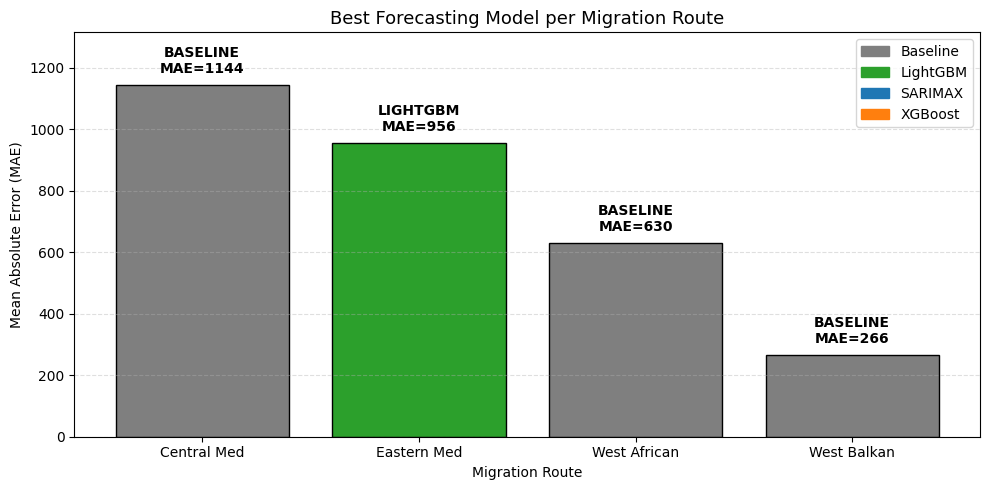

In [ ]:
# τελικό γράφημα: καλύτερο μοντέλο ανά migration route

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# αντιγραφή του τελικού dashboard table
df_plot = dashboard_table.copy()

#  σύντομα ονόματα routes για καθαρότερο γράφημα
short_routes = ["Central Med", "Eastern Med", "West African", "West Balkan"]

# μοντέλο που κέρδισε σε κάθε route
models = df_plot["Best_Model"].tolist()

#  σταθερά χρώματα για κάθε μοντέλο
color_map = {
    "BASELINE": "#7f7f7f",
    "LIGHTGBM": "#2ca02c",
    "SARIMAX": "#1f77b4",
    "XGBOOST": "#ff7f0e"
}

# δημιουργία λίστας χρωμάτων για τις μπάρες
colors = [color_map[m] for m in models]

#  δημιουργία figure
plt.figure(figsize=(10,5))

# δημιουργία bar chart
bars = plt.bar(short_routes, df_plot["MAE_best"], color=colors, edgecolor="black")

#  labels πάνω από κάθε bar (μοντέλο + MAE)
for bar, model in zip(bars, models):

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 30,
        f"{model}\nMAE={height:.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

#  τίτλος και labels αξόνων
plt.title("Best Forecasting Model per Migration Route", fontsize=13)
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Migration Route")

# grid για καλύτερη αναγνωσιμότητα
plt.grid(axis="y", linestyle="--", alpha=0.4)

#  αυξάνει λίγο το όριο του y-axis για να μην κόβεται το label
plt.ylim(0, df_plot["MAE_best"].max() * 1.15)

# legend για τα μοντέλα
legend_handles = [
    mpatches.Patch(color=color_map["BASELINE"], label="Baseline"),
    mpatches.Patch(color=color_map["LIGHTGBM"], label="LightGBM"),
    mpatches.Patch(color=color_map["SARIMAX"], label="SARIMAX"),
    mpatches.Patch(color=color_map["XGBOOST"], label="XGBoost")
]

plt.legend(handles=legend_handles, loc="upper right")

# layout για σωστή στοίχιση
plt.tight_layout()

# εμφάνιση γράφηματος
plt.show()

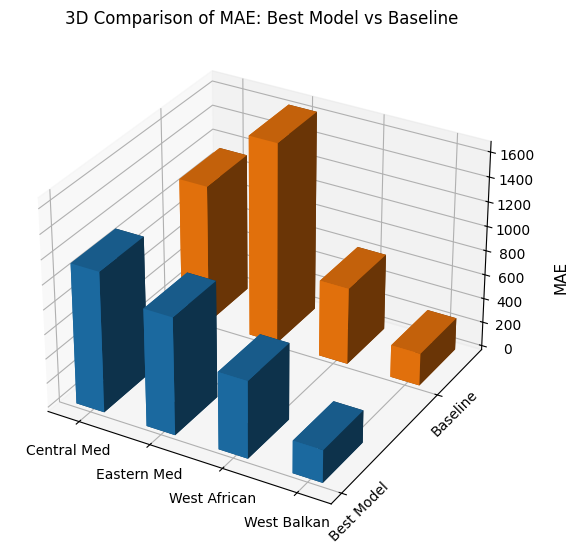

In [ ]:
# 3D bar chart για σύγκριση MAE best model vs baseline

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

routes = dashboard_table["Route"].tolist()

# συντομευμένες ονομασίες routes για να μη μετακινούν το γράφημα εκτός κέντρου
short_routes = ["Central Med", "Eastern Med", "West African", "West Balkan"]

# θέσεις στον άξονα x
xpos = np.arange(len(routes))

# δύο σειρές: 0 = Best Model, 1 = Baseline
ypos_model = np.zeros(len(routes))
ypos_base = np.ones(len(routes))

zpos = np.zeros(len(routes))

dx = np.full(len(routes), 0.4)
dy = np.full(len(routes), 0.4)

dz_model = dashboard_table["MAE_best"].values
dz_base = dashboard_table["MAE_baseline"].values

fig = plt.figure(figsize=(13, 7))
ax = fig.add_subplot(111, projection="3d")

# μπάρες best model
ax.bar3d(xpos, ypos_model, zpos, dx, dy, dz_model, shade=True)

# μπάρες baseline
ax.bar3d(xpos, ypos_base, zpos, dx, dy, dz_base, shade=True)

# labels
ax.set_title("3D Comparison of MAE: Best Model vs Baseline")

ax.set_yticks([0, 1])
ax.set_yticklabels(["Best Model", "Baseline"], rotation=45, va="center")
fig.text(0.72, 0.55, "MAE", rotation=90, va="center", ha="center", fontsize=11)
ax.set_xticks(xpos + 0.2)
ax.set_xticklabels(short_routes, rotation=0, ha="center")


plt.subplots_adjust(left=0.08, right=0.90, bottom=0.18, top=0.9)
plt.show()

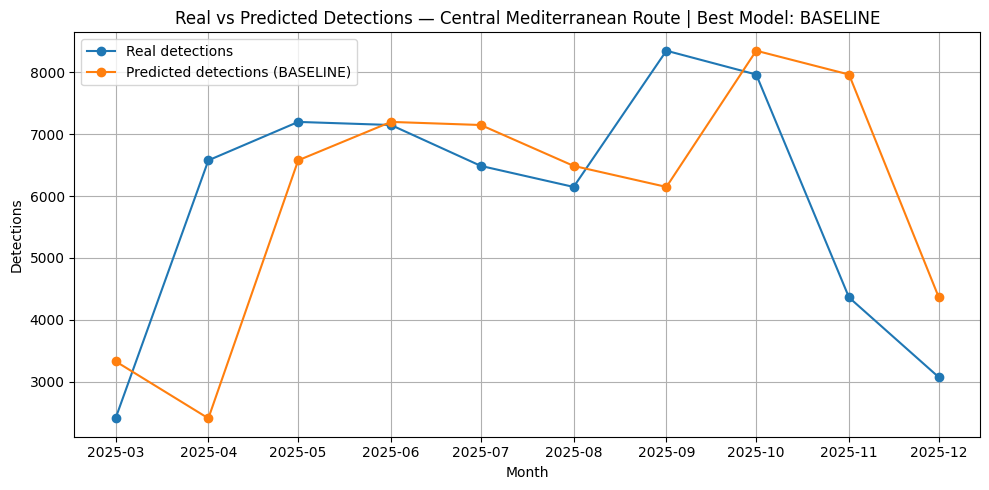

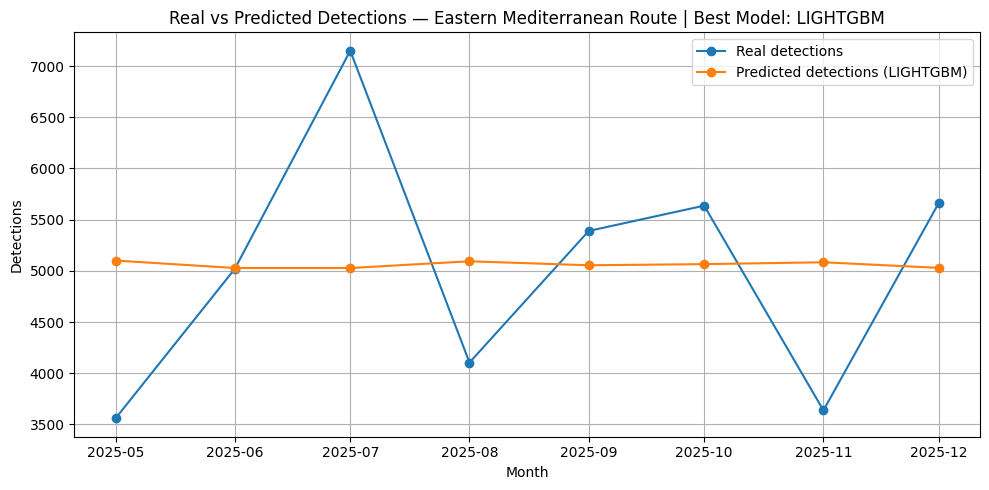

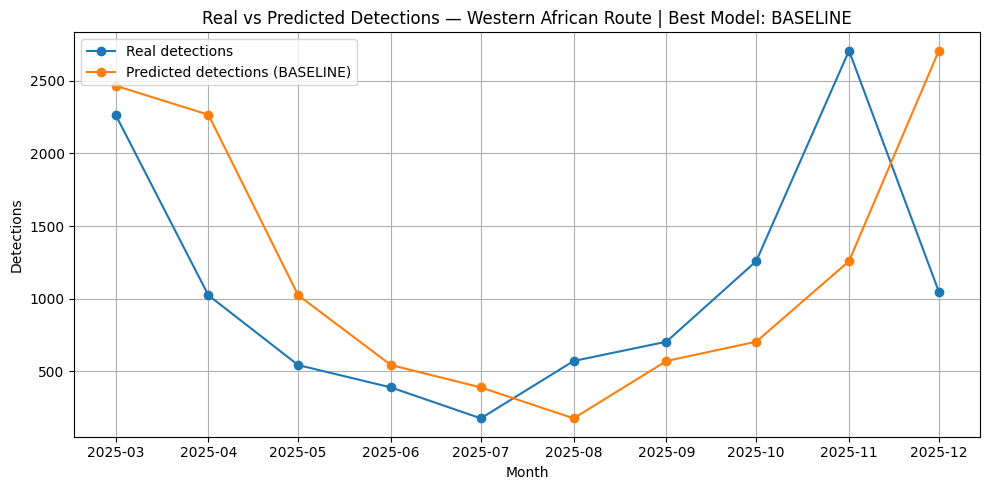

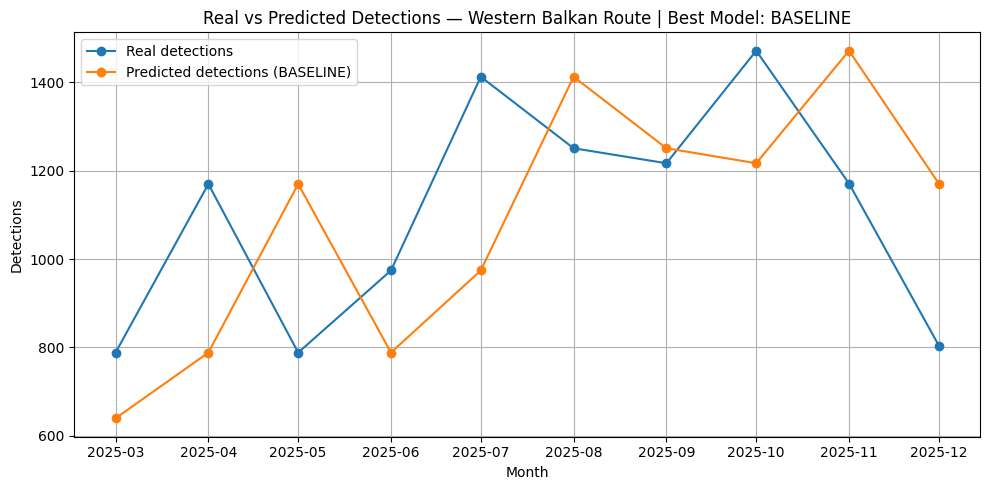

In [ ]:
# σύγκριση πραγματικών και προβλεπόμενων detections με το καλύτερο μοντέλο ανά route

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import warnings

warnings.filterwarnings("ignore")

# επανάληψη για κάθε migration route
for r, df_r in route_datasets.items():

    df_r = df_r.copy()

    # σωστό datetime index και μηνιαία συχνότητα
    df_r.index = pd.DatetimeIndex(df_r.index).to_period("M").to_timestamp()
    df_r = df_r.sort_index().asfreq("MS")

    # βρίσκει το καλύτερο μοντέλο για το route
    best_model_name = best_models_df.loc[
        best_models_df["Route"] == r, "Model"
    ].iloc[0]

    # features για τα ML / SARIMAX μοντέλα
    exog_cols = [
        "push_events_sum",
        "avg_sentiment_wavg",
        "t2m",
        "u10",
        "detections_lag1",
        "detections_lag2",
        "detections_lag3",
        "detections_roll3"
    ]

    #  baseline route
    if best_model_name == "BASELINE":

        df_r = df_r.dropna(subset=["total_detections"] + ["detections_lag1"])

        real_vals = []
        pred_vals = []
        months = []

        for i in range(24, len(df_r)):

            train = df_r.iloc[:i]
            test = df_r.iloc[i:i+1]

            # baseline = προηγούμενος μήνας
            pred = float(df_r["total_detections"].iloc[i - 1])
            real = float(test["total_detections"].iloc[0])
            month = test.index[0]

            pred_vals.append(pred)
            real_vals.append(real)
            months.append(month)

    # SARIMAX / XGBOOST / LIGHTGBM
    else:

        df_r = df_r.dropna(subset=["total_detections"] + exog_cols)

        real_vals = []
        pred_vals = []
        months = []

        for i in range(24, len(df_r)):

            train = df_r.iloc[:i]
            test = df_r.iloc[i:i+1]

            y_train_log = np.log1p(train["total_detections"].astype("float64"))

            X_train = train[exog_cols].astype("float64")
            X_test = test[exog_cols].astype("float64")

            # ---> SARIMAX
            if best_model_name == "SARIMAX":

                mu = X_train.mean(axis=0)
                sd = X_train.std(axis=0, ddof=0).replace(0.0, 1.0)

                exog_train = (X_train - mu) / sd
                exog_test = (X_test - mu) / sd

                model = SARIMAX(
                    y_train_log,
                    exog=exog_train,
                    order=(1, 0, 0),
                    seasonal_order=(0, 0, 0, 0),
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )

                try:
                    res = model.fit(disp=False, method="lbfgs", maxiter=500)
                except Exception:
                    res = model.fit(disp=False, method="powell", maxiter=500)

                pred_log = res.forecast(steps=1, exog=exog_test).iloc[0]
                pred = float(np.expm1(pred_log))

            # ---> XGBOOST
            elif best_model_name == "XGBOOST":

                model = XGBRegressor(
                    n_estimators=200,
                    max_depth=3,
                    learning_rate=0.05,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    objective="reg:squarederror",
                    random_state=42
                )

                model.fit(X_train, y_train_log)
                pred_log = model.predict(X_test)[0]
                pred = float(np.expm1(pred_log))

            # ---> LIGHTGBM
            elif best_model_name == "LIGHTGBM":

                model = LGBMRegressor(
                    n_estimators=200,
                    learning_rate=0.05,
                    max_depth=3,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    random_state=42,
                    verbose=-1
                )

                model.fit(X_train, y_train_log)
                pred_log = model.predict(X_test)[0]
                pred = float(np.expm1(pred_log))

            real = float(test["total_detections"].iloc[0])
            month = test.index[0]

            pred_vals.append(pred)
            real_vals.append(real)
            months.append(month)

    #  γράφημα σύγκρισης
    plt.figure(figsize=(10, 5))

    plt.plot(months, real_vals, marker="o", label="Real detections")
    plt.plot(months, pred_vals, marker="o", label=f"Predicted detections ({best_model_name})")

    plt.title(f"Real vs Predicted Detections — {r} | Best Model: {best_model_name}")
    plt.ylabel("Detections")
    plt.xlabel("Month")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

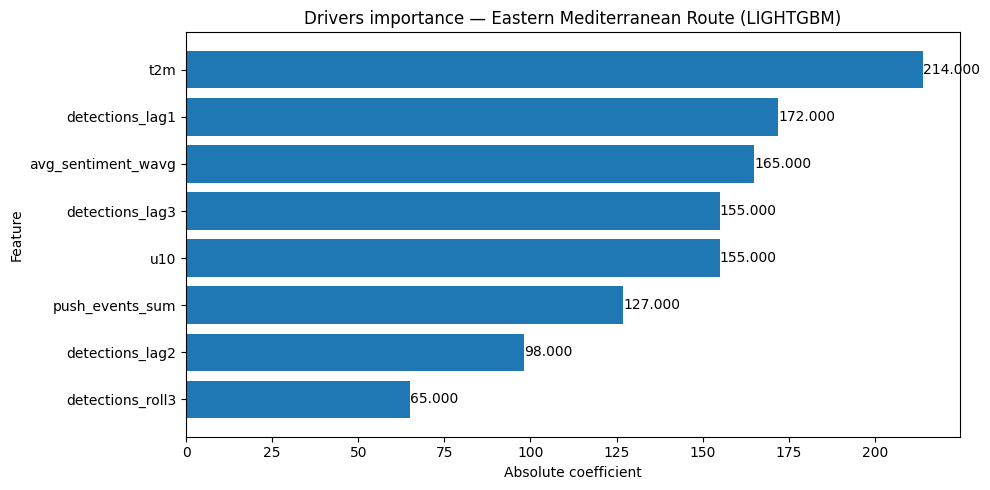

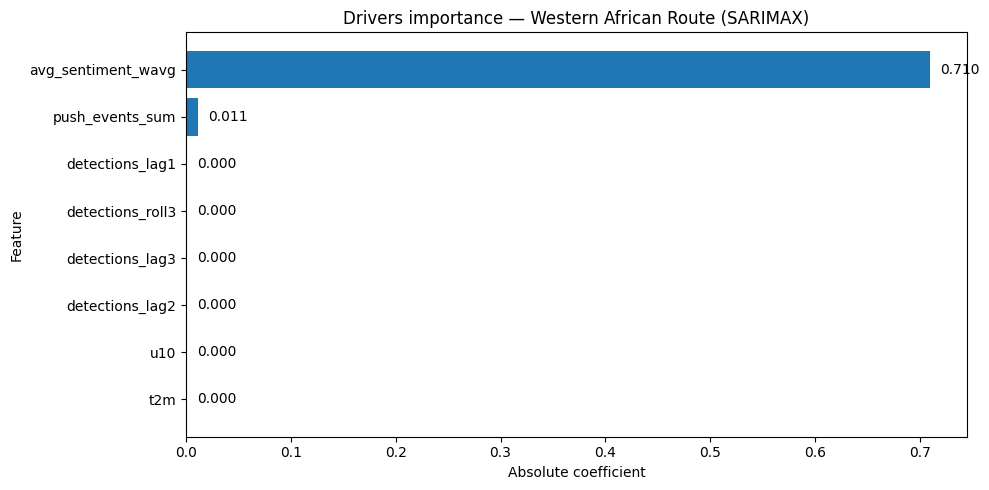

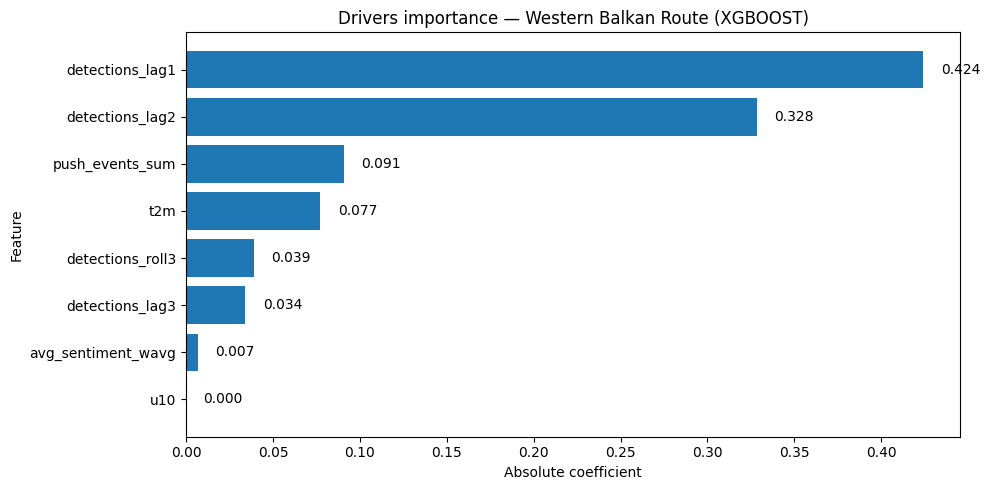

                         Route     Model           Feature  AbsCoefficient
0  Eastern Mediterranean Route  LIGHTGBM  detections_roll3            65.0
1  Eastern Mediterranean Route  LIGHTGBM   detections_lag2            98.0
2  Eastern Mediterranean Route  LIGHTGBM   push_events_sum           127.0
3  Eastern Mediterranean Route  LIGHTGBM               u10           155.0
4  Eastern Mediterranean Route  LIGHTGBM   detections_lag3           155.0
['Route', 'Model', 'Feature', 'AbsCoefficient']


In [ ]:
# feature importance για τα best models + αποθήκευση σε importance_df

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ---> λίστα για αποθήκευση importance όλων των routes
importance_rows = []

# χειροκίνητο mapping για να εμφανίζονται όλα τα μοντέλα
manual_models = {
    "Eastern Mediterranean Route": "LIGHTGBM",
    "Western African Route": "SARIMAX",
    "Western Balkan Route": "XGBOOST"
}

for r, model_name in manual_models.items():

    df_r = route_datasets[r].copy()

    # σωστό datetime index και μηνιαία συχνότητα
    df_r.index = pd.DatetimeIndex(df_r.index).to_period("M").to_timestamp()
    df_r = df_r.sort_index().asfreq("MS")

    # features
    exog_cols = [
        "push_events_sum",
        "avg_sentiment_wavg",
        "t2m",
        "u10",
        "detections_lag1",
        "detections_lag2",
        "detections_lag3",
        "detections_roll3"
    ]

    # κρατάει μόνο πλήρεις γραμμές
    df_r = df_r.dropna(subset=["total_detections"] + exog_cols)

    X = df_r[exog_cols].astype("float64")
    y = np.log1p(df_r["total_detections"].astype("float64"))

    # XGBOOST
    if model_name == "XGBOOST":

        model = XGBRegressor(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            random_state=42
        )

        model.fit(X, y)
        importance = model.feature_importances_

    # LIGHTGBM
    elif model_name == "LIGHTGBM":
        if r == "Eastern Mediterranean Route":
            model = LGBMRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.9,
                colsample_bytree=0.9,
                random_state=42,
                verbose=-1,
                min_child_samples=1,
                num_leaves=7
            )
        else:
            model = LGBMRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.9,
                colsample_bytree=0.9,
                random_state=42,
                verbose=-1
            )

        model.fit(X, y)
        importance = model.feature_importances_

    # SARIMAX
    elif model_name == "SARIMAX":

        from statsmodels.tsa.statespace.sarimax import SARIMAX

        model = SARIMAX(
            y,
            exog=X,
            order=(1, 0, 0),
            seasonal_order=(0, 0, 0, 0),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        res = model.fit(disp=False)

        params_series = pd.Series(res.params, index=res.param_names)
        importance = params_series[exog_cols].abs().values

    # dataframe για plotting και export
    df_plot = pd.DataFrame({
        "Route": r,
        "Model": model_name,
        "Feature": exog_cols,
        "AbsCoefficient": importance
    }).sort_values("AbsCoefficient", ascending=True)

    # αποθήκευση όλων των γραμμών στη λίστα
    importance_rows.append(df_plot)

    # γράφημα
    plt.figure(figsize=(10, 5))

    bars = plt.barh(df_plot["Feature"], df_plot["AbsCoefficient"])

    for bar in bars:
        w = bar.get_width()
        plt.text(
            w + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{w:.3f}",
            va="center"
        )

    plt.title(f"Drivers importance — {r} ({model_name})")
    plt.xlabel("Absolute coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# ενιαίο dataframe για dashboard export
importance_df = pd.concat(importance_rows, axis=0, ignore_index=True)

# έλεγχος
print(importance_df.head())
print(importance_df.columns.tolist())

In [ ]:
# export actual vs predicted ανά μήνα για dashboard

import pandas as pd
import numpy as np
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")

pred_rows = []

for r, df_r in route_datasets.items():

    # σωστό datetime index και μηνιαία συχνότητα
    df_r = df_r.copy()
    df_r.index = pd.DatetimeIndex(df_r.index).to_period("M").to_timestamp()
    df_r = df_r.sort_index().asfreq("MS")

    # βρίσκει το καλύτερο μοντέλο για το route
    best_model_name = best_models_df.loc[
        best_models_df["Route"] == r, "Model"
    ].iloc[0]

    # features για τα μοντέλα
    exog_cols = [
        "push_events_sum",
        "avg_sentiment_wavg",
        "t2m",
        "u10",
        "detections_lag1",
        "detections_lag2",
        "detections_lag3",
        "detections_roll3"
    ]

    #  baseline route
    if best_model_name == "BASELINE":

        df_r = df_r.dropna(subset=["total_detections", "detections_lag1"])

        for i in range(24, len(df_r)):

            train = df_r.iloc[:i]
            test = df_r.iloc[i:i+1]

            pred_val = float(df_r["total_detections"].iloc[i - 1])
            actual_val = float(test["total_detections"].iloc[0])
            month_val = test.index[0]

            pred_rows.append({
                "Route": r,
                "Best_Model": best_model_name,
                "Month": month_val,
                "Actual_detections": actual_val,
                "Predicted_detections": pred_val
            })

    # routes με SARIMAX / XGBOOST / LIGHTGBM
    else:

        df_r = df_r.dropna(subset=["total_detections"] + exog_cols)

        for i in range(24, len(df_r)):

            train = df_r.iloc[:i]
            test = df_r.iloc[i:i+1]

            y_train_log = np.log1p(train["total_detections"].astype("float64"))

            X_train = train[exog_cols].astype("float64")
            X_test = test[exog_cols].astype("float64")

            # ---> SARIMAX
            if best_model_name == "SARIMAX":

                mu = X_train.mean(axis=0)
                sd = X_train.std(axis=0, ddof=0).replace(0.0, 1.0)

                exog_train = (X_train - mu) / sd
                exog_test = (X_test - mu) / sd

                model = SARIMAX(
                    y_train_log,
                    exog=exog_train,
                    order=(1, 0, 0),
                    seasonal_order=(0, 0, 0, 0),
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )

                try:
                    res = model.fit(disp=False, method="lbfgs", maxiter=500)
                except Exception:
                    res = model.fit(disp=False, method="powell", maxiter=500)

                pred_log = res.forecast(steps=1, exog=exog_test).iloc[0]
                pred_val = float(np.expm1(pred_log))

            # ---> XGBOOST
            elif best_model_name == "XGBOOST":

                model = XGBRegressor(
                    n_estimators=200,
                    max_depth=3,
                    learning_rate=0.05,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    objective="reg:squarederror",
                    random_state=42
                )

                model.fit(X_train, y_train_log)
                pred_log = model.predict(X_test)[0]
                pred_val = float(np.expm1(pred_log))

            # ---> LIGHTGBM
            elif best_model_name == "LIGHTGBM":

                if r == "Eastern Mediterranean Route":
                    model = LGBMRegressor(
                        n_estimators=200,
                        learning_rate=0.05,
                        max_depth=3,
                        subsample=0.9,
                        colsample_bytree=0.9,
                        random_state=42,
                        verbose=-1,
                        min_child_samples=1,
                        num_leaves=7
                    )
                else:
                    model = LGBMRegressor(
                        n_estimators=200,
                        learning_rate=0.05,
                        max_depth=3,
                        subsample=0.9,
                        colsample_bytree=0.9,
                        random_state=42,
                        verbose=-1
                    )

                model.fit(X_train, y_train_log)
                pred_log = model.predict(X_test)[0]
                pred_val = float(np.expm1(pred_log))

            actual_val = float(test["total_detections"].iloc[0])
            month_val = test.index[0]

            pred_rows.append({
                "Route": r,
                "Best_Model": best_model_name,
                "Month": month_val,
                "Actual_detections": actual_val,
                "Predicted_detections": pred_val
            })

#  τελικό dataframe
forecast_monthly_df = pd.DataFrame(pred_rows)

# export για dashboard
forecast_monthly_df.to_csv("forecast_monthly.csv", index=False)

# έλεγχος
print(forecast_monthly_df.head())
print("forecast_monthly.csv saved")

                         Route Best_Model      Month  Actual_detections  \
0  Central Mediterranean Route   BASELINE 2025-03-01             2407.0   
1  Central Mediterranean Route   BASELINE 2025-04-01             6578.0   
2  Central Mediterranean Route   BASELINE 2025-05-01             7199.0   
3  Central Mediterranean Route   BASELINE 2025-06-01             7149.0   
4  Central Mediterranean Route   BASELINE 2025-07-01             6488.0   

   Predicted_detections  
0                3329.0  
1                2407.0  
2                6578.0  
3                7199.0  
4                7149.0  
forecast_monthly.csv saved


In [ ]:
# Φόρτωση τελικού joined dataset (GDELT push + Frontex detections)
# Βάση για παραγωγή visualisations και ML datasets

final_path = "/content/drive/MyDrive/gdelt_push_frontex_joined.parquet"

df_final = spark.read.parquet(final_path)

# Έλεγχος δείγματος
df_final.show(10, truncate=False)

+--------------+----------------+-----------+-------------+-------------------+---------------------------+------------+----------+----------------+----------------+
|event_loc_name|event_month_year|push_events|push_mentions|avg_sentiment      |Route                      |target_month|year_month|total_detections|year_month_label|
+--------------+----------------+-----------+-------------+-------------------+---------------------------+------------+----------+----------------+----------------+
|Eritrea       |202510          |11         |45.0         |-8.374278292458339 |Central Mediterranean Route|202511      |202511    |4361            |NOV2025         |
|Eritrea       |202502          |7          |27.0         |-6.867470156737249 |Central Mediterranean Route|202503      |202503    |2407            |MAR2025         |
|Eritrea       |202509          |7          |38.0         |-7.08739348070309  |Central Mediterranean Route|202510      |202510    |7965            |OCT2025         |
|Eri

In [ ]:
# Visuals set σε επίπεδο Route–μήνα
# Συγκεντρώνει push factors και detections ανά διαδρομή και μήνα-στόχο

df_visuals_route = (
    df_final
    .groupBy("Route", "target_month", "year_month_label")
    .agg(
        F.sum("push_events").alias("push_events_sum"),
        F.sum("push_mentions").alias("push_mentions_sum"),
        F.avg("avg_sentiment").alias("avg_sentiment_mean"),
        F.sum("total_detections").alias("total_detections_sum")
    )
    .orderBy("Route", "target_month")
)

# Έλεγχος δείγματος
df_visuals_route.show(20, truncate=False)

# Αποθήκευση visuals dataset για γραφήματα
visuals_route_path = "/content/drive/MyDrive/gdelt_visuals_route_month.parquet"

df_visuals_route.write.mode("overwrite").parquet(visuals_route_path)

print("Saved visuals dataset (Route–μήνας) at:", visuals_route_path)

+---------------------------+------------+----------------+---------------+-----------------+-------------------+--------------------+
|Route                      |target_month|year_month_label|push_events_sum|push_mentions_sum|avg_sentiment_mean |total_detections_sum|
+---------------------------+------------+----------------+---------------+-----------------+-------------------+--------------------+
|Central Mediterranean Route|202302      |FEB2023         |1658           |23046.0          |-6.560749564204601 |66262               |
|Central Mediterranean Route|202303      |MAR2023         |1445           |11078.0          |-5.512372831834869 |92869               |
|Central Mediterranean Route|202304      |APR2023         |1159           |10008.0          |-5.421171224663597 |102179              |
|Central Mediterranean Route|202305      |MAY2023         |1854           |20352.0          |-5.358592794292364 |57078               |
|Central Mediterranean Route|202306      |JUN2023      

In [ ]:
# αποθήκευση των τελικών πινάκων για χρήση σε dashboard

#  αποθήκευση του βασικού πίνακα αποτελεσμάτων
dashboard_table.to_csv("/content/drive/MyDrive/dashboard_table.csv", index=False)

#  αποθήκευση του βασικού πίνακα αποτελεσμάτων
try:
    importance_df.to_csv("/content/drive/MyDrive/drivers_importance.csv", index=False)
    print("drivers_importance.csv saved")
except NameError:
    print("drivers_importance.csv not created")

#  επιβεβαίωση αποθήκευσης
print("dashboard_table.csv saved")

forecast_monthly_df.to_csv("/content/drive/MyDrive/forecast_monthly.csv", index=False)
print("forecast_monthly.csv saved to Drive")

drivers_importance.csv saved
dashboard_table.csv saved
forecast_monthly.csv saved to Drive
